# Rain Tomorrow — classificação binária e estabilidade temporal

**Projeto 04 da Mentoria em Ciência de Dados.** Estimar a probabilidade de chover no dia seguinte (`RainTomorrow = Yes`)
com **Regressão Logística** e responder à pergunta central:

> *Um modelo de Regressão Logística desenvolvido com dados meteorológicos históricos mantém sua capacidade de discriminar
> chuva e não chuva quando aplicado a um período futuro?*

**Como este notebook se relaciona com os scripts.** O notebook é a narrativa analítica; a solução executável está em `src/` e
`scripts/`. Ordem de execução documentada no README:

1. `python scripts/train.py` — seleção de modelo no TRAIN, congelamento (`artifacts/model.joblib` + hash SHA-256);
2. `python scripts/evaluate.py` — avaliação do modelo congelado no OOT 2017;
3. este notebook — usa as **mesmas funções de `src/`** e confere, com `assert`, que reproduz os artefatos dos scripts.

**Regra do OOT neste notebook.** Até a seção 10, nada de 2017 é inspecionado além de contagens estruturais
(linhas, localidades, meses), exigidas pelo enunciado. O conjunto de 2017 é descartado logo após essas contagens
e só é recarregado na seção 10, depois de verificar o hash do modelo congelado.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from src import config, plots
from src.artifacts import load_frozen_model, read_json
from src.data import load_raw, split_development_oot, drop_missing_target, load_train_test, get_xy, assert_no_oot
from src.metrics import discrimination_metrics, evaluate_scores, threshold_metrics, metrics_by_group
from src.modeling import (build_pipeline, run_model_selection, evaluate_candidates, coefficient_table,
                          persistence_score)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.4f}".format)
plots.apply_style()
%matplotlib inline

import platform, sklearn
print("Python", platform.python_version(), "| scikit-learn", sklearn.__version__, "| pandas", pd.__version__,
      "| numpy", np.__version__)

Python 3.11.9 | scikit-learn 1.9.0 | pandas 3.0.5 | numpy 2.4.6


## 1. Entendimento do problema e dos dados

**Fonte:** Kaggle *Rain in Australia* (`weatherAUS.csv`, Version 2), observações diárias do Australian Bureau of Meteorology (BoM)
compiladas pelo projeto Rattle. **Uma linha = uma estação (`Location`) em um dia (`Date`)**, com medições do dia e o alvo
`RainTomorrow`: choveu mais de 1 mm no dia seguinte?

In [2]:
raw = load_raw(config.DATA_PATH)
print("formato:", raw.shape)
print("intervalo de datas:", raw["Date"].min().date(), "->", raw["Date"].max().date())
print("duplicatas (Location, Date):", int(raw.duplicated(["Location", "Date"]).sum()))
print("RISK_MM presente:", "RISK_MM" in raw.columns)
display(raw.head())
display(raw.dtypes.rename("dtype").to_frame().T)

formato: (145460, 23)


intervalo de datas: 2007-11-01 -> 2017-06-25
duplicatas (Location, Date): 0
RISK_MM presente: False


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4000,22.9000,0.6000,NaN,NaN,W,44.0000,W,WNW,20.0000,24.0000,71.0000,22.0000,1007.7000,1007.1000,8.0000,NaN,16.9000,21.8000,No,No
1,2008-12-02,Albury,7.4000,25.1000,0.0000,NaN,NaN,WNW,44.0000,NNW,WSW,4.0000,22.0000,44.0000,25.0000,1010.6000,1007.8000,NaN,NaN,17.2000,24.3000,No,No
2,2008-12-03,Albury,12.9000,25.7000,0.0000,NaN,NaN,WSW,46.0000,W,WSW,19.0000,26.0000,38.0000,30.0000,1007.6000,1008.7000,NaN,2.0000,21.0000,23.2000,No,No
3,2008-12-04,Albury,9.2000,28.0000,0.0000,NaN,NaN,NE,24.0000,SE,E,11.0000,9.0000,45.0000,16.0000,1017.6000,1012.8000,NaN,NaN,18.1000,26.5000,No,No
4,2008-12-05,Albury,17.5000,32.3000,1.0000,NaN,NaN,W,41.0000,ENE,NW,7.0000,20.0000,82.0000,33.0000,1010.8000,1006.0000,7.0000,8.0000,17.8000,29.7000,No,No


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
dtype,datetime64[us],str,float64,float64,float64,float64,float64,str,float64,str,str,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str,str


### 1.1 Estrutura temporal (contagens estruturais, inclusive de 2017)

O enunciado pede para verificar quantas observações e localidades existem em 2017 **antes** de separar o OOT. As contagens abaixo são
puramente estruturais: não olham target nem valores de features de 2017.

In [3]:
by_year = raw.groupby(raw["Date"].dt.year).agg(linhas=("Location", "size"), localidades=("Location", "nunique"))
display(by_year.T)

dev, oot_sealed = split_development_oot(raw)
structural_2017 = {
    "linhas": len(oot_sealed),
    "localidades": oot_sealed["Location"].nunique(),
    "primeira data": str(oot_sealed["Date"].min().date()),
    "última data": str(oot_sealed["Date"].max().date()),
    "linhas sem RainTomorrow": int(oot_sealed["RainTomorrow"].isna().sum()),
    "localidades de 2017 ausentes antes de 2017": sorted(set(oot_sealed["Location"]) - set(dev["Location"])),
}
display(pd.Series(structural_2017, name="OOT 2017 (estrutura)").to_frame())
display(oot_sealed["Date"].dt.to_period("M").value_counts().sort_index().rename("linhas por mês (2017)").to_frame().T)

# O OOT é descartado aqui e só volta na seção 10, depois do congelamento do modelo.
del oot_sealed, raw
assert_no_oot(dev)
print(f"Desenvolvimento: {len(dev)} linhas, {dev['Date'].min().date()} -> {dev['Date'].max().date()}")

Date,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
linhas,61,2270,16789,16782,15407,15409,16415,17885,17885,17934,8623
localidades,1,23,46,46,46,46,49,49,49,49,49


,OOT 2017 (estrutura)
linhas,8623
localidades,49
primeira data,2017-01-01
última data,2017-06-25
linhas sem RainTomorrow,157
localidades de 2017 ausentes antes de 2017,[]


Date,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06
linhas por mês (2017),1519,1372,1519,1470,1519,1224


Desenvolvimento: 136837 linhas, 2007-11-01 -> 2016-12-31


In [4]:
full_months = pd.period_range(dev["Date"].min(), dev["Date"].max(), freq="M")
present = set(dev["Date"].dt.to_period("M"))
print("meses inteiramente ausentes no histórico:", [str(m) for m in full_months if m not in present])
coverage = dev.groupby("Location")["Date"].agg(inicio="min", fim="max", linhas="size")
display(coverage.sort_values("inicio").groupby("inicio").size().rename("nº de localidades por data de início").to_frame())

meses inteiramente ausentes no histórico: ['2011-04', '2012-12', '2013-02']


,nº de localidades por data de início
inicio,
2007-11-01,1
2008-02-01,1
2008-07-01,6
2008-12-01,15
2009-01-01,23
2013-03-01,3


**Leitura.** O histórico começa com uma única estação (Canberra, nov/2007), passa a 46 estações em 2009 e 49 a partir de
mar/2013 (Nhil, Uluru e Katherine). Três meses faltam por completo. O OOT 2017 cobre **apenas janeiro a junho** (junho até o dia 25):
isso importa para drift e para a taxa de chuva, porque o TRAIN cobre o ano inteiro.

### 1.2 Variável alvo (somente histórico < 2017)

RainTomorrow
No     103613
Yes     30114
NaN      3110
proporção Yes (entre rotuladas): 0.2252 | No: 0.7748


Date,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
n,61.0000,2246.0000,16595.0000,16419.0000,15126.0000,15044.0000,16097.0000,17400.0000,17231.0000,17508.0000
taxa_yes,0.3115,0.2275,0.2174,0.2434,0.2471,0.2253,0.2153,0.2044,0.2117,0.2389


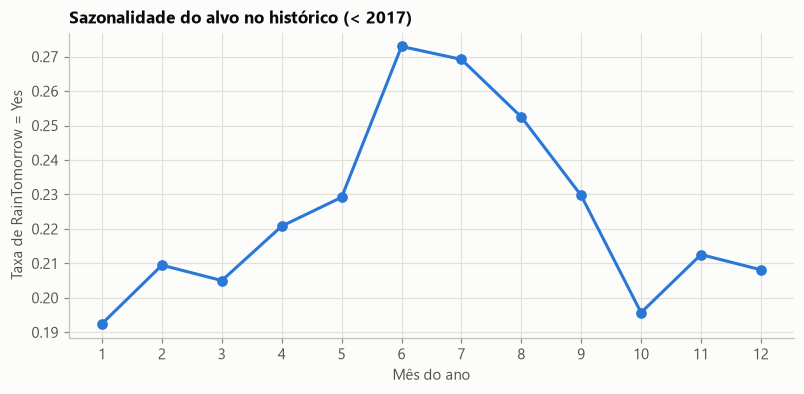

In [5]:
counts = dev["RainTomorrow"].value_counts(dropna=False)
labelled = dev["RainTomorrow"].dropna()
print(counts.to_string())
print(f"proporção Yes (entre rotuladas): {(labelled == 'Yes').mean():.4f} | No: {(labelled == 'No').mean():.4f}")

rate_year = dev.dropna(subset=["RainTomorrow"]).groupby(dev["Date"].dt.year)["RainTomorrow"].agg(
    n="size", taxa_yes=lambda s: (s == "Yes").mean())
rate_month = dev.dropna(subset=["RainTomorrow"]).groupby(dev["Date"].dt.month)["RainTomorrow"].agg(
    n="size", taxa_yes=lambda s: (s == "Yes").mean())
display(rate_year.T)

fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.plot(rate_month.index, rate_month["taxa_yes"], color=plots.SERIES[0], marker="o", markersize=6)
ax.set(xticks=range(1, 13), xlabel="Mês do ano", ylabel="Taxa de RainTomorrow = Yes",
       title="Sazonalidade do alvo no histórico (< 2017)")
plt.show()

**Leitura.** A classe positiva é minoritária (cerca de 22,5% das linhas rotuladas). Uma regra que sempre responde "No" teria
accuracy ≈ 77,5% sem discriminar nada — por isso a accuracy não é usada para comparar modelos. A taxa de chuva é sazonal
(mínimo em janeiro, máximo em junho/julho), e o OOT só tem janeiro–junho.

### 1.3 Tipos, missing values e cardinalidade (histórico)

In [6]:
missing = dev.isna().mean().sort_values(ascending=False).rename("fração_missing")
display(missing.to_frame().T)

numeric_cols = config.NUMERIC_FEATURES
struct = (dev.groupby("Location")[numeric_cols + ["WindGustDir", "WindDir9am", "WindDir3pm"]]
          .agg(lambda s: s.isna().mean()) >= 0.95)
structural = struct.sum().loc[lambda s: s > 0].rename("nº de estações com >= 95% de missing")
display(structural.to_frame().T)

complete = dev.dropna(subset=["RainTomorrow"])[numeric_cols].notna().all(axis=1)
print(f"linhas rotuladas com as 16 numéricas completas: {complete.sum()} de {len(complete)} ({complete.mean():.1%})")

cardinality = {c: dev[c].nunique() for c in config.CATEGORICAL_FEATURES}
print("cardinalidade das categóricas:", cardinality)

,Sunshine,Evaporation,Cloud3pm,Cloud9am,Pressure9am,Pressure3pm,WindDir9am,WindGustDir,WindGustSpeed,Humidity3pm,WindDir3pm,RainTomorrow,Rainfall,RainToday,Temp3pm,WindSpeed3pm,Humidity9am,WindSpeed9am,Temp9am,MinTemp,MaxTemp,Date,Location
fração_missing,0.4636,0.4168,0.3993,0.3790,0.1036,0.1033,0.0728,0.0715,0.0711,0.0286,0.0279,0.0227,0.0227,0.0227,0.0225,0.0197,0.0185,0.0126,0.0125,0.0101,0.0086,0.0000,0.0000


,Evaporation,Sunshine,WindGustSpeed,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,WindGustDir
nº de estações com >= 95% de missing,17,19,2,4,4,12,12,2


linhas rotuladas com as 16 numéricas completas: 56325 de 133727 (42.1%)
cardinalidade das categóricas: {'Location': 49, 'WindGustDir': 16, 'WindDir9am': 16, 'WindDir3pm': 16, 'RainToday': 2}


**Leitura e decisões.**
- A ausência de `Sunshine`, `Evaporation`, `Cloud*` e `Pressure*` é **estrutural**: há estações que nunca medem essas variáveis.
  Descartar linhas incompletas jogaria fora mais da metade do histórico. Decisão: imputar pela **mediana do TRAIN** e testar,
  na CV, **indicadores de missing** (a variante é escolhida pelo protocolo da seção 8).
- `Location` (49 níveis) e as direções de vento (16 pontos cardeais) entram como categóricas com one-hot.

In [7]:
for t in ["9am", "3pm"]:
    d, v = dev[f"WindDir{t}"], dev[f"WindSpeed{t}"]
    print(f"WindDir{t}: {int(d.isna().sum())} NaN; destes, WindSpeed{t} == 0 em {int((d.isna() & v.eq(0)).sum())}; "
          f"linhas com WindSpeed{t} == 0: {int(v.eq(0).sum())} (todas sem direção: {bool(d[v.eq(0)].isna().all())})")

WindDir9am: 9957 NaN; destes, WindSpeed9am == 0 em 8185; linhas com WindSpeed9am == 0: 8185 (todas sem direção: True)
WindDir3pm: 3822 NaN; destes, WindSpeed3pm == 0 em 1067; linhas com WindSpeed3pm == 0: 1067 (todas sem direção: True)


**Direção do vento ausente ≈ calmaria.** Toda linha com vento de 0 km/h às 9h não tem direção registrada, e a maioria dos
`NaN` de `WindDir9am` vem daí. Imputar pela moda inventaria uma direção; a decisão é uma **categoria própria `"missing"`**
(imputação constante antes do one-hot).

### 1.4 Valores inconsistentes e outliers (histórico)

In [8]:
desc = dev[numeric_cols].describe(percentiles=[0.01, 0.5, 0.99]).T
display(desc)
checks = {
    "MinTemp > MaxTemp": int((dev["MinTemp"] > dev["MaxTemp"]).sum()),
    "umidade fora de [0, 100]": int(((dev[["Humidity9am", "Humidity3pm"]] < 0) | (dev[["Humidity9am", "Humidity3pm"]] > 100)).any(axis=1).sum()),
    "valores negativos (chuva, evaporação, sol, vento)": int((dev[["Rainfall", "Evaporation", "Sunshine", "WindGustSpeed", "WindSpeed9am", "WindSpeed3pm"]] < 0).any(axis=1).sum()),
    "Cloud fora de [0, 8] oitavos": int(((dev[["Cloud9am", "Cloud3pm"]] > 8)).any(axis=1).sum()),
    "Rainfall == 0 (fração)": round(float(dev["Rainfall"].eq(0).mean()), 4),
    "Evaporation > 60 mm": int((dev["Evaporation"] > 60).sum()),
}
display(pd.Series(checks, name="verificação").to_frame())

,count,mean,std,min,1%,50%,99%,max
MinTemp,135458.0000,12.0985,6.3749,-8.5000,-1.9000,11.9000,25.7000,33.9000
MaxTemp,135657.0000,23.1074,7.1080,-4.8000,8.9000,22.5000,40.0000,48.1000
Rainfall,133728.0000,2.3534,8.4564,0.0000,0.0000,0.0000,37.2000,371.0000
Evaporation,79800.0000,5.4426,4.1677,0.0000,0.4000,4.6000,18.2000,145.0000
Sunshine,73394.0000,7.6092,3.7856,0.0000,0.0000,8.4000,13.4000,14.5000
WindGustSpeed,127114.0000,40.1929,13.6489,6.0000,15.0000,39.0000,81.0000,135.0000
WindSpeed9am,135119.0000,14.1156,8.9467,0.0000,0.0000,13.0000,39.0000,87.0000
WindSpeed3pm,134136.0000,18.7508,8.8370,0.0000,2.0000,19.0000,43.0000,87.0000
Humidity9am,134312.0000,68.7320,19.0382,0.0000,17.0000,70.0000,100.0000,100.0000
Humidity3pm,132924.0000,51.5212,20.7927,0.0000,8.0000,52.0000,98.0000,100.0000


,verificação
MinTemp > MaxTemp,0.0000
"umidade fora de [0, 100]",0.0000
"valores negativos (chuva, evaporação, sol, vento)",0.0000
"Cloud fora de [0, 8] oitavos",3.0000
Rainfall == 0 (fração),0.6247
Evaporation > 60 mm,21.0000


**Leitura.** Não há inconsistências lógicas. `Rainfall` e `Evaporation` têm cauda longa (muitos zeros; máximos de 371 mm e 145 mm).
As notas do BoM avisam que, após dias sem medição, chuva e evaporação podem vir **acumuladas de vários dias**, o que explica parte
dos extremos. Não removo outliers (seriam decisões sem critério externo); a variante `log1p` para essas duas variáveis é avaliada
na CV. Três leituras de nuvem valem 9 (fora da escala 0–8) e são mantidas: o efeito é desprezível.

### 1.5 O que exatamente é o alvo — e que informação existe no momento da previsão

Verificação direta nos dados (histórico): `RainTomorrow` do dia *t* é o `RainToday` do dia *t+1* da mesma estação, e `RainToday`
é `Rainfall > 1 mm`.

In [9]:
s = dev.sort_values(["Location", "Date"])
nxt = s.groupby("Location")[["Date", "RainToday", "Temp9am"]].shift(-1)
consecutive = (nxt["Date"] - s["Date"]).dt.days.eq(1)
m = consecutive & s["RainTomorrow"].notna() & nxt["RainToday"].notna()
print(f"RainTomorrow(t) == RainToday(t+1): {(s.loc[m, 'RainTomorrow'] == nxt.loc[m, 'RainToday']).mean():.5f} (n = {int(m.sum())})")
rt = dev.dropna(subset=["Rainfall", "RainToday"])
print(f"RainToday == (Rainfall > 1.0): {((rt['Rainfall'] > 1.0) == rt['RainToday'].eq('Yes')).mean():.5f}; "
      f"linhas com Rainfall == 1.0 marcadas 'No': {int(rt.loc[rt['Rainfall'] == 1.0, 'RainToday'].eq('No').sum())}")
windows = pd.Series(config.FEATURE_WINDOWS, name="janela de medição (BoM)").to_frame()
display(windows)

RainTomorrow(t) == RainToday(t+1): 1.00000 (n = 133546)
RainToday == (Rainfall > 1.0): 1.00000; linhas com Rainfall == 1.0 marcadas 'No': 1683


,janela de medição (BoM)
MinTemp,24h até 09:00 de t
Rainfall,24h até 09:00 de t
RainToday,24h até 09:00 de t
Evaporation,24h até 09:00 de t
Temp9am,instante 09:00 de t
Humidity9am,instante 09:00 de t
Cloud9am,instante 09:00 de t
Pressure9am,instante 09:00 de t
WindDir9am,média 10 min antes de 09:00 de t
WindSpeed9am,média 10 min antes de 09:00 de t


**Pergunta de revisão: qual informação está disponível no momento em que queremos prever se choverá amanhã?**

Pelo cartão do dataset, a chuva de um dia é medida *"nas 24 horas até as 9h"*. Logo o alvo de *t* é a chuva **entre 09:00 de *t* e
09:00 de *t+1***. Pelas notas do BoM (tabela acima): `MinTemp`, `Rainfall`, `RainToday`, `Evaporation` e as leituras das 9h fecham
**antes** dessa janela; as leituras das 15h, `Sunshine` e `WindGust*` (até a meia-noite) caem **dentro** dela; `MaxTemp` é o
máximo das 24h **a partir** das 9h, isto é, a **mesma janela do alvo**, fechando só às 09:00 de *t+1*.

Consequências para o desenho do experimento:
- o modelo é tratado como uma previsão **emitida ao fim do dia *t*** (00:00 de *t+1*), com as observações do dia;
- **`MaxTemp` fica fora do modelo final** (20 features): é a única variável cuja janela termina *depois* desse momento
  (às 09:00 de *t+1*, junto com o alvo), portanto seria informação formalmente futura;
- parte da janela do alvo (09:00–24:00 de *t*) já transcorreu no momento da previsão: o problema é parcialmente *nowcasting*;
- a análise de sensibilidade da seção 8 compara o conjunto final com as 21 features (com `MaxTemp`) e com um conjunto restrito
  ao que existe às 09:00 de *t*.

A checagem abaixo confirma empiricamente a janela de `MaxTemp`: se ela fosse o máximo do dia civil, a temperatura das 9h do dia
seguinte ultrapassaria o `MaxTemp` de vez em quando (como `MinTemp` ultrapassa a leitura das 15h do mesmo dia).

In [10]:
tol = 0.5
ok_next = consecutive & nxt["Temp9am"].notna() & s["MaxTemp"].notna()
print(f"Temp9am(t+1) > MaxTemp(t) + {tol}: {(nxt.loc[ok_next, 'Temp9am'] > s.loc[ok_next, 'MaxTemp'] + tol).mean():.4%} (n = {int(ok_next.sum())})")
ok_same = s["MinTemp"].notna() & s["Temp3pm"].notna()
print(f"MinTemp(t) > Temp3pm(t) + {tol}:     {(s.loc[ok_same, 'MinTemp'] > s.loc[ok_same, 'Temp3pm'] + tol).mean():.4%} (n = {int(ok_same.sum())})")

Temp9am(t+1) > MaxTemp(t) + 0.5: 0.0037% (n = 134775)
MinTemp(t) > Temp3pm(t) + 0.5:     0.5842% (n = 133346)


## 2. Classificação binária — vocabulário aplicado ao projeto

| Conceito | Neste projeto |
|---|---|
| **Classe positiva / negativa** | Positiva = `RainTomorrow = Yes` (chuva > 1 mm entre 09:00 de *t* e 09:00 de *t+1*). É o evento que se quer antecipar e a classe minoritária; precision, recall e PR-AUC são definidas em torno dela. |
| **Score / probabilidade** | `predict_proba` devolve `[P(No), P(Yes)]` por linha; o score é a coluna `P(Yes)`. É uma estimativa de P(chuva \| observações do dia); a leitura como frequência depende da calibração (verificada na seção 9). |
| **Threshold** | A decisão Yes/No surge ao comparar o score com um corte *t* (Yes se score ≥ *t*). **Neste projeto nenhum corte é escolhido**; `predict.py` devolve a probabilidade. |
| **TP / FP / TN / FN** | TP: previu chuva e choveu. FP: previu chuva e não choveu (alarme falso). TN: previu tempo seco e não choveu. FN: previu tempo seco e choveu (a pessoa é pega desprevenida). |
| **Accuracy** | (TP + TN) / N. Engana em classe desbalanceada: responder sempre "No" acerta ~77,5% do histórico sem identificar nenhum dia de chuva. |
| **Precision** | TP / (TP + FP): dos dias em que o modelo avisou chuva, quantos choveram. |
| **Recall / Sensitivity** | TP / (TP + FN): dos dias que choveram, quantos o modelo avisou. |
| **Specificity** | TN / (TN + FP): dos dias secos, quantos o modelo reconheceu como secos. |
| **F1** | Média harmônica de precision e recall; como ambas dependem do corte, F1 também depende. |
| **ROC-AUC** | Probabilidade de um dia chuvoso sorteado receber score maior que um dia seco sorteado; resume TPR × FPR em todos os cortes. 0,5 = ordenação aleatória. Não depende da prevalência. |
| **PR-AUC** | Aqui calculada como *Average Precision*: precision média ao longo dos níveis de recall. O patamar de um modelo sem habilidade é a **prevalência**, então ela muda quando a taxa de chuva muda, mesmo que a ordenação seja a mesma. Mais informativa quando a classe positiva é rara, porque ignora os TN. |
| **KS** | Maior distância vertical entre as distribuições acumuladas dos scores de dias chuvosos e secos, igual a max(TPR − FPR). Mede separação no melhor ponto de corte, sem fixar um corte operacional. |

ROC-AUC, PR-AUC e KS usam apenas a **ordenação dos scores**, por isso avaliam discriminação sem threshold. São as três métricas de
comparação do projeto; as dependentes de threshold aparecem só para ilustração (seção 9).

## 3. Regressão Logística em alto nível

- **Por que "regressão" se é classificação?** O modelo regride o *log-odds* da classe positiva como função linear das features,
  `log(p / (1 − p)) = b0 + b1·x1 + … + bk·xk`. A saída é uma probabilidade; vira classe só quando se aplica um threshold.
- **Sigmoid.** `p = 1 / (1 + e^(−z))` leva qualquer `z` real para (0, 1). Como é ajustada por máxima verossimilhança da Bernoulli,
  a saída tem interpretação probabilística.
- **Coeficientes e intercepto.** `bj` é a variação no log-odds por unidade de `xj` (aqui, por desvio-padrão, pois as numéricas são
  padronizadas); `exp(bj)` é a razão de chances. O intercepto é o log-odds quando todas as features valem zero (as médias do TRAIN,
  após a padronização).
- **Regularização.** Penaliza a magnitude dos coeficientes para reduzir variância. **L2** encolhe todos suavemente; **L1** pode zerar
  alguns (seleção de variáveis). No scikit-learn, **`C` é o inverso da força**: C menor → mais regularização. Na versão 1.9 o
  parâmetro `penalty` está obsoleto; o tipo é dado por `l1_ratio` (0 = L2, 1 = L1). Solvers: `lbfgs` para L2, `saga` para L1.
- **`class_weight`.** Dá mais peso aos erros de uma classe; `"balanced"` usa pesos inversamente proporcionais às frequências. Pode
  ajudar quando a classe positiva é rara e o objetivo é recall, mas **desloca as probabilidades para cima** (elas deixam de refletir a
  prevalência real), e a ordenação — o que ROC-AUC, PR-AUC e KS medem — muda pouco. Por isso entra na grade, mas `None` tem
  preferência no desempate.
- **StandardScaler.** A penalização trata todos os coeficientes igualmente; sem escala comparável, uma variável em hPa (~1000) e
  outra em oitavos (0–8) seriam penalizadas de forma desigual. Padronizar também acelera a convergência e torna os coeficientes comparáveis.

## 4. Out-of-Time: separado antes de qualquer fit

A separação já aconteceu na seção 1.1: `split_development_oot` cortou em `Date < 2017-01-01` (desenvolvimento) e `Date >= 2017-01-01`
(OOT), e o OOT foi descartado da memória. No código, `load_development_data` descarta o OOT logo após a leitura e `assert_no_oot`
protege toda rotina de ajuste (`split_train_test`, `evaluate_candidates`, `run_model_selection`). `scripts/train.py` nunca lê 2017
(há teste automatizado verificando isso).

O OOT responde a uma pergunta diferente do teste aleatório: **"o modelo já definido funciona num período posterior ao que o gerou?"**
O teste aleatório mistura dias de todos os anos e mede generalização dentro do mesmo período.

## 5. Split treino/teste no histórico (80/20, estratificado, `random_state=42`)

**Escolha 80/20.** Com ~134 mil linhas rotuladas, 20% dá um teste com cerca de 6 mil dias de chuva — suficiente para métricas com
intervalos estreitos — e deixa mais dados para o treino. O ajuste de hiperparâmetros é feito por CV **dentro do TRAIN**, então o
TEST não é usado para escolher nada. `stratify=y` preserva a taxa de chuva nos dois lados. Linhas sem `RainTomorrow` (dia seguinte
sem medição) são removidas antes do split.

In [11]:
data = load_train_test()
train, test = data["train"], data["test"]
X_train, y_train = get_xy(train)
X_test, y_test = get_xy(test)
split_summary = pd.DataFrame({
    "linhas": [data["n_dev_rows"], data["n_dropped_missing_target"], len(train), len(test)],
}, index=["histórico < 2017", "removidas (sem target)", "TRAIN", "TEST"])
display(split_summary.T)
print(f"prevalência TRAIN {y_train.mean():.4f} | TEST {y_test.mean():.4f}")
assert train["Date"].max() < pd.Timestamp(config.OOT_START) and test["Date"].max() < pd.Timestamp(config.OOT_START)
assert not set(train.index) & set(test.index)

,histórico < 2017,removidas (sem target),TRAIN,TEST
linhas,136837,3110,106981,26746


prevalência TRAIN 0.2252 | TEST 0.2252


## 6. Data leakage — onde poderia acontecer e como foi evitado

| Tipo | Risco concreto neste dataset | Proteção |
|---|---|---|
| Informação futura | `RainTomorrow(t) = RainToday(t+1)`: qualquer *lead* de chuva é o próprio alvo. `RISK_MM` (chuva do dia seguinte) existe em versões antigas. `MaxTemp` fecha às 09:00 de *t+1*. | Só colunas brutas; nenhuma feature usa linhas futuras; `RISK_MM` não existe nesta versão e seria ignorado (`remainder="drop"`). `MaxTemp` excluída do modelo final (seção 1.5); aparece só na análise de sensibilidade. |
| Preprocessing | Medianas, médias/desvios ou categorias calculados com TEST ou OOT. | Tudo dentro de um único `Pipeline`, ajustado só no TRAIN (e, na CV, só no fold de treino). Testes conferem que as estatísticas do modelo salvo são as do TRAIN. |
| Contaminação do OOT | Olhar 2017, mudar features/C e reavaliar 2017. | Protocolo de seleção pré-registrado em `config.py`; modelo congelado com hash antes de abrir 2017; `evaluate.py` não chama `fit`. |
| Feature temporal | Ano como feature (extrapola para 2017), agregados por estação com o período inteiro. | Só dia do ano (seno/cosseno); nenhum agregado; nenhum target encoding. |
| Split aleatório | Dias vizinhos da mesma estação são muito parecidos e caem em TRAIN e TEST → teste otimista. | Não é vazamento proibido, mas limita o que o TEST responde; por isso o OOT existe e é a avaliação temporal. |

## 7. Preprocessing reproduzível

**Features do modelo final (20 brutas + 2 derivadas de `Date`):** 15 numéricas (`MinTemp`, `Rainfall`, `Evaporation`, `Sunshine`,
`WindGustSpeed`, `WindSpeed9am`, `WindSpeed3pm`, `Humidity9am`, `Humidity3pm`, `Pressure9am`, `Pressure3pm`, `Cloud9am`, `Cloud3pm`,
`Temp9am`, `Temp3pm`), 5 categóricas (`Location`, `WindGustDir`, `WindDir9am`, `WindDir3pm`, `RainToday`) e seno/cosseno do dia do ano.

`ColumnTransformer` + `Pipeline`, ajustados somente no TRAIN:

- numéricas → [log1p em `Rainfall`/`Evaporation`, se a variante for escolhida] → `SimpleImputer(median)` [+ indicadores de missing] → `StandardScaler`
- categóricas (`Location`, direções do vento, `RainToday`) → `SimpleImputer(constant="missing")` → `OneHotEncoder(handle_unknown="ignore")`
- `Date` → seno e cosseno do dia do ano (sem ano)
- qualquer outra coluna é descartada (`remainder="drop"`)

In [12]:
display(build_pipeline(feature_set=config.FINAL_FEATURE_SET, preprocessing="indicators_log"))

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('num_log', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.

## 8. Baseline e ajuste da Regressão Logística

### 8.1 Baseline
Configuração simples, registrada no TEST antes de qualquer ajuste: preprocessing `base` (mediana + scaler; categorias com
`"missing"` + one-hot) e `LogisticRegression` padrão (C = 1, L2, `lbfgs`).

In [13]:
frozen_metrics = read_json(config.METRICS_PATH)
frozen_meta = read_json(config.METADATA_PATH)

baseline_params = {"feature_set": config.FINAL_FEATURE_SET, "preprocessing": config.BASELINE_PREPROCESSING,
                   **config.BASELINE_MODEL_PARAMS}
baseline = build_pipeline(**baseline_params).fit(X_train, y_train)
baseline_test = evaluate_scores(y_test, baseline.predict_proba(X_test)[:, 1])
display(pd.DataFrame([baseline_test])[["n", "prevalence", "roc_auc", "roc_auc_ci_low", "roc_auc_ci_high",
                                       "pr_auc", "pr_auc_ci_low", "pr_auc_ci_high", "ks", "ks_ci_low", "ks_ci_high"]])
for m in ("roc_auc", "pr_auc", "ks"):
    assert abs(baseline_test[m] - frozen_metrics["baseline"]["test"][m]) < 1e-12  # mesmo valor registrado por train.py

,n,prevalence,roc_auc,roc_auc_ci_low,roc_auc_ci_high,pr_auc,pr_auc_ci_low,pr_auc_ci_high,ks,ks_ci_low,ks_ci_high
0,26746,0.2252,0.8751,0.8701,0.8802,0.7126,0.7016,0.7236,0.5821,0.5717,0.5947


### 8.2 Protocolo de seleção (pré-registrado em `src/config.py`, somente TRAIN)

- **Validação:** `StratifiedKFold(5, shuffle=True, random_state=42)` dentro do TRAIN; o pipeline inteiro é reajustado em cada fold.
- **Métrica de seleção: ROC-AUC médio.** A pergunta central é sobre *discriminar* chuva de não chuva; a ROC-AUC mede exatamente a
  ordenação e não depende da prevalência. PR-AUC e KS são registradas para todos os candidatos.
- **Regra de 1 erro-padrão:** entre os candidatos cuja média fica a até 1 EP (desvio-padrão entre folds / √5) do melhor, escolhe-se o
  primeiro na ordem de preferência — o mais simples/regularizado. Diferenças menores que o ruído entre folds não justificam mais
  complexidade.
- **Estágio 1 — preprocessing** (com a LR baseline): `base` → `indicators` (indicadores de missing) → `indicators_log` (+ log1p em
  `Rainfall`/`Evaporation`).
- **Estágio 2 — hiperparâmetros:** C ∈ {0,001; 0,01; 0,1; 1; 10; 100} × penalty {L2, L1} × `class_weight` {None, balanced}.
  Ordem de preferência: `None` antes de `balanced` (mantém a probabilidade na escala da prevalência observada), menor C antes, L2 antes de L1.

A célula abaixo reexecuta toda a seleção (≈ 10 min, 135 ajustes) e confere que chega à mesma escolha congelada por `train.py`.

In [14]:
selection = run_model_selection(X_train, y_train, feature_set=config.FINAL_FEATURE_SET)
cv_results = selection["cv_results"]
selected = selection["selected_params"]
cols = ["stage", "preprocessing", "C", "penalty", "class_weight", "roc_auc_mean", "roc_auc_se", "pr_auc_mean",
        "pr_auc_se", "ks_mean", "ks_se", "selected"]
display(cv_results[cols].assign(class_weight=cv_results["class_weight"].fillna("None")))
print("selecionado:", selected)

frozen_cv = pd.read_csv(config.CV_RESULTS_PATH)
np.testing.assert_allclose(cv_results["roc_auc_mean"], frozen_cv["roc_auc_mean"], rtol=0, atol=1e-12)
assert selected["preprocessing"] == frozen_meta["model"]["preprocessing_variant"]
assert selected["C"] == frozen_meta["model"]["C"] and selected["l1_ratio"] == frozen_meta["model"]["l1_ratio"]
assert selected["class_weight"] == frozen_meta["model"]["class_weight"]

,stage,preprocessing,C,penalty,class_weight,roc_auc_mean,roc_auc_se,pr_auc_mean,pr_auc_se,ks_mean,ks_se,selected
0,1_preprocessing,base,1.0000,l2,None,0.8731,0.0008,0.7063,0.0024,0.5814,0.0018,False
1,1_preprocessing,indicators,1.0000,l2,None,0.8743,0.0007,0.7084,0.0024,0.5833,0.0017,True
2,1_preprocessing,indicators_log,1.0000,l2,None,0.8749,0.0008,0.7101,0.0023,0.5847,0.0016,False
3,2_hyperparameters,indicators,0.0010,l2,None,0.8676,0.0008,0.6929,0.0023,0.5694,0.0022,False
4,2_hyperparameters,indicators,0.0010,l1,None,0.8580,0.0008,0.6786,0.0023,0.5509,0.0025,False
5,2_hyperparameters,indicators,0.0100,l2,None,0.8733,0.0007,0.7053,0.0023,0.5804,0.0015,False
6,2_hyperparameters,indicators,0.0100,l1,None,0.8682,0.0005,0.6954,0.0021,0.5703,0.0019,False
7,2_hyperparameters,indicators,0.1000,l2,None,0.8742,0.0007,0.7083,0.0023,0.5830,0.0019,True
8,2_hyperparameters,indicators,0.1000,l1,None,0.8742,0.0007,0.7081,0.0023,0.5826,0.0019,False
9,2_hyperparameters,indicators,1.0000,l2,None,0.8743,0.0007,0.7084,0.0024,0.5833,0.0017,False


selecionado: {'feature_set': 'full_without_maxtemp', 'preprocessing': 'indicators', 'C': 0.1, 'l1_ratio': 0.0, 'class_weight': None}


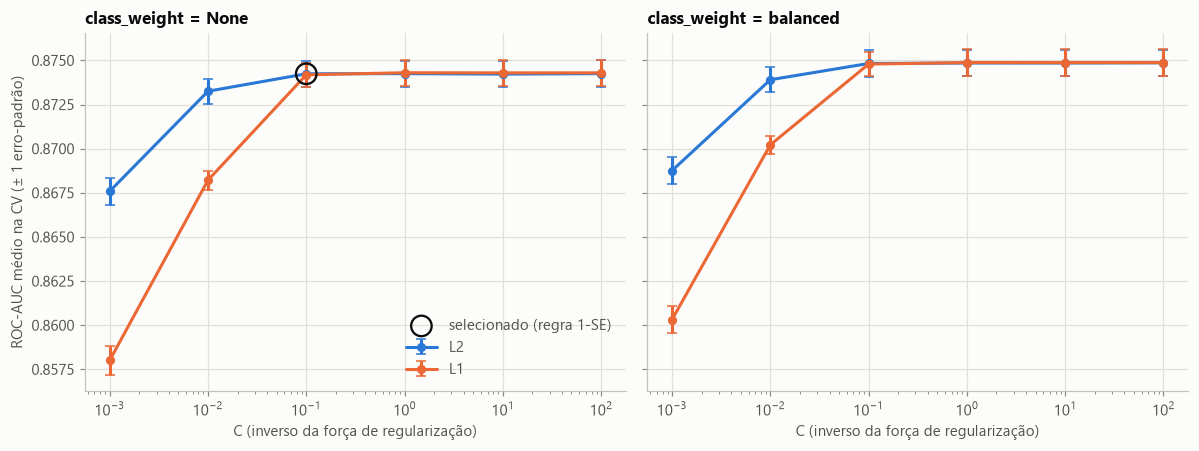

In [15]:
plots.plot_cv_path(cv_results)
plt.show()

**Leitura da seleção (CV no TRAIN, 20 features).**
- **Estágio 1.** Os indicadores de missing elevam o ROC-AUC médio de 0,8731 (`base`) para 0,8743, ganho maior que 1 erro-padrão
  (≈ 0,0008). O `log1p` em `Rainfall`/`Evaporation` acrescenta mais 0,0006 (0,8749), dentro de 1 EP do melhor; pela regra, fica a
  variante mais simples, `indicators`.
- **Estágio 2.** A partir de C = 0,1 o ROC-AUC é praticamente constante (0,8742–0,8749 em todas as combinações): com ~107 mil linhas
  e 135 colunas, a regularização quase não altera o ajuste. Só a regularização forte (C ≤ 0,01) piora — e piora mais com L1, que zera
  coeficientes.
- **`class_weight`.** Com `"balanced"` o ROC-AUC é ~0,0006 maior e a PR-AUC ~0,0035 menor que com `None` no mesmo C; a diferença de
  ROC-AUC fica dentro de 1 EP e a ordem de preferência escolhe `None`, que mantém as probabilidades na escala da prevalência real.
- **Escolha congelada:** `indicators`, C = 0,1, L2 (`lbfgs`), `class_weight=None` — a configuração mais regularizada entre as
  indistinguíveis da melhor. ROC-AUC na CV: 0,8742 (EP 0,0007).

### 8.3 Análise de sensibilidade: informação disponível até as 09:00 × ao fim do dia

Mesma configuração congelada; só muda o conjunto de features. **É informativa** — não alterou a escolha do modelo e não é avaliada
no OOT. Conjuntos: `full_without_maxtemp` (**modelo final**, 20 features, tudo fechado até o fim do dia *t*), `full` (21 features,
inclui `MaxTemp`, cuja janela fecha às 09:00 de *t+1*) e `morning` (apenas o que existe às 09:00 de *t*: `MinTemp`, `Rainfall`,
`RainToday`, `Evaporation`, leituras das 9h e `Location`).

In [16]:
sensitivity = pd.read_csv(config.SENSITIVITY_PATH)
base_params = {k: v for k, v in selected.items() if k != "feature_set"}
recheck = evaluate_candidates([{"feature_set": fs, **base_params} for fs in sensitivity["feature_set"]], X_train, y_train)
np.testing.assert_allclose(recheck["roc_auc_mean"], sensitivity["cv_roc_auc_mean"], rtol=0, atol=1e-12)
display(sensitivity.drop(columns=["features"]))

,feature_set,is_final_model,n_raw_features,cv_roc_auc_mean,cv_roc_auc_se,cv_pr_auc_mean,cv_pr_auc_se,cv_ks_mean,cv_ks_se,test_roc_auc,test_pr_auc,test_ks
0,full,False,21,0.8744,0.0007,0.7089,0.0022,0.5830,0.0017,0.8756,0.7135,0.5838
1,full_without_maxtemp,True,20,0.8742,0.0007,0.7083,0.0023,0.5830,0.0019,0.8757,0.7138,0.5839
2,morning,False,11,0.8117,0.0013,0.5684,0.0025,0.4731,0.0037,0.8159,0.5808,0.4760


**Leitura.**
- **Retirar `MaxTemp` não tem custo mensurável:** ROC-AUC na CV 0,8742 (20 features) × 0,8744 (21), diferença de 0,0002 ≈ 0,3 EP;
  no TEST, 0,8757 × 0,8756. A exclusão, decidida por validade temporal (seção 1.5), não sacrifica desempenho — as leituras da tarde
  já carregam essa informação.
- **Restringir ao que existe às 09:00 derruba o desempenho:** ROC-AUC 0,8117 (−0,063), PR-AUC 0,568 (−0,140), KS 0,473 (−0,110) na
  CV. Boa parte da capacidade do modelo vem de observações da tarde (umidade e pressão das 15h, rajada, sol), que caem dentro da
  janela do alvo. O problema, como definido no dataset, é em parte *nowcasting*: quem precisasse decidir às 9h teria um modelo
  bem pior.
- Estes números são de CV no TRAIN e do TEST. Nenhum conjunto alternativo é avaliado no OOT.

## 9. Modelo final e avaliação no TEST (registrada antes de abrir o OOT)

O modelo final é o pipeline selecionado ajustado em todo o TRAIN. Carrego o artefato congelado (hash verificado) e confiro que um
reajuste aqui no notebook produz exatamente os mesmos coeficientes.

In [17]:
model, meta = load_frozen_model()
print("modelo congelado em", meta["frozen_at_utc"], "| sha256", meta["model_sha256"][:16], "...")
refit = build_pipeline(**selected).fit(X_train, y_train)
np.testing.assert_allclose(refit.named_steps["model"].coef_, model.named_steps["model"].coef_, rtol=0, atol=1e-10)

s_train = model.predict_proba(X_train)[:, 1]
s_test = model.predict_proba(X_test)[:, 1]
train_m = discrimination_metrics(y_train, s_train)
test_m = evaluate_scores(y_test, s_test)
for m in ("roc_auc", "pr_auc", "ks"):
    assert abs(test_m[m] - frozen_metrics["test"][m]) < 1e-12
persist_test = discrimination_metrics(y_test, persistence_score(X_test))
summary = pd.DataFrame({
    "TRAIN (in-sample)": {m: train_m[m] for m in ("roc_auc", "pr_auc", "ks")},
    "TEST": {m: test_m[m] for m in ("roc_auc", "pr_auc", "ks")},
    "TEST IC95% inf": {m: test_m[f"{m}_ci_low"] for m in ("roc_auc", "pr_auc", "ks")},
    "TEST IC95% sup": {m: test_m[f"{m}_ci_high"] for m in ("roc_auc", "pr_auc", "ks")},
    "baseline (TEST)": {m: baseline_test[m] for m in ("roc_auc", "pr_auc", "ks")},
    "persistência RainToday (TEST)": {m: persist_test[m] for m in ("roc_auc", "pr_auc", "ks")},
    "sem habilidade": {"roc_auc": 0.5, "pr_auc": float(y_test.mean()), "ks": 0.0},
}).T
display(summary)

modelo congelado em 2026-09-28T22:41:09+00:00 | sha256 b274388f39b24a33 ...


,roc_auc,pr_auc,ks
TRAIN (in-sample),0.8754,0.7104,0.5846
TEST,0.8757,0.7138,0.5839
TEST IC95% inf,0.8707,0.7026,0.5739
TEST IC95% sup,0.8807,0.7254,0.5970
baseline (TEST),0.8751,0.7126,0.5821
persistência RainToday (TEST),0.6608,0.3410,0.3220
sem habilidade,0.5000,0.2252,0.0000


**Leitura (TEST: 26.746 dias, prevalência 0,2252).**
- **ROC-AUC 0,8757** [IC95% 0,8707–0,8807]: sorteando um dia chuvoso e um seco, o modelo dá score maior ao chuvoso em cerca de
  87,6% dos pares.
- **PR-AUC 0,7138** [0,7026–0,7254], contra 0,2252 de um classificador sem habilidade (a prevalência).
- **KS 0,5839** [0,5739–0,5970]: no melhor ponto de corte, as distribuições acumuladas de scores de dias secos e chuvosos ficam
  58,4 pontos percentuais distantes.
- **TRAIN in-sample (0,8754 / 0,7104 / 0,5846) ≈ TEST:** não há sinal de sobreajuste, o esperado para um modelo linear regularizado
  com ~107 mil linhas. Isso também mostra o limite do TEST aleatório: ele mede o desempenho dentro do mesmo período; a pergunta
  temporal é respondida pelo OOT.
- **Sobre o baseline** (0,8751 / 0,7126 / 0,5821), a seleção acrescenta pouco (+0,0006 de ROC-AUC, dentro do IC): o desempenho vem
  das features, não do ajuste fino de hiperparâmetros.
- **Persistência** ("amanhã chove se choveu hoje"): ROC-AUC 0,6608 e PR-AUC 0,3410 — o modelo acrescenta muito sobre ela.

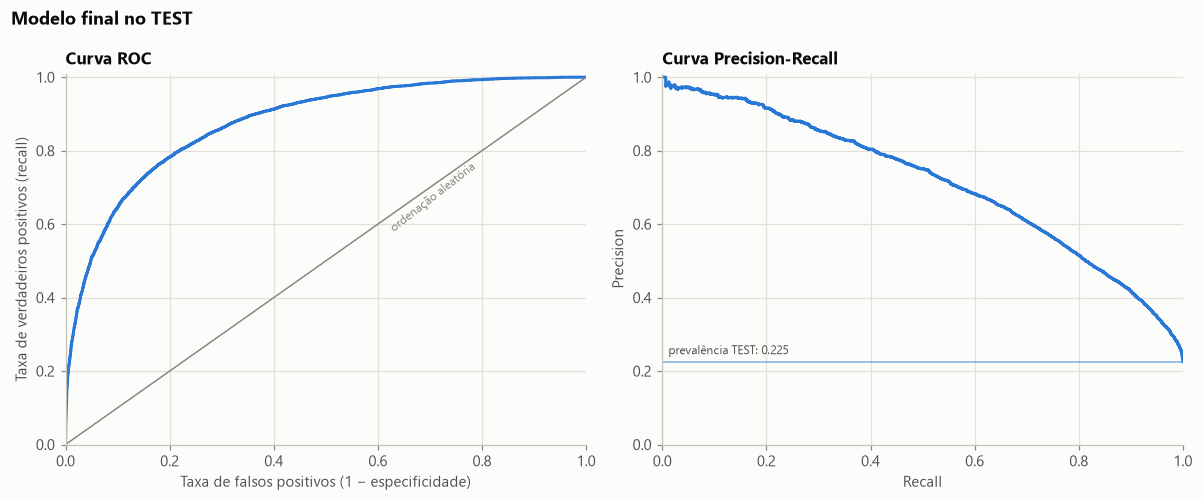

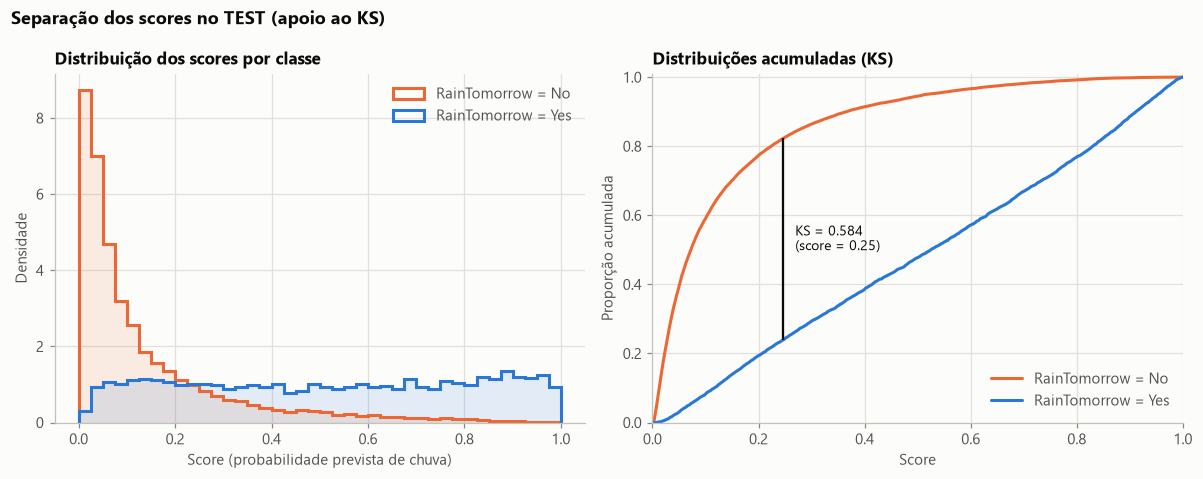

In [18]:
plots.plot_roc_pr({"TEST": (y_test, s_test)}, title="Modelo final no TEST")
plt.show()
plots.plot_score_distributions(y_test, s_test, title="Separação dos scores no TEST (apoio ao KS)")
plt.show()

### 9.1 Threshold: por que ele muda a matriz de confusão (ilustração, nenhum corte é escolhido)

In [19]:
thr = pd.DataFrame([threshold_metrics(y_test, s_test, t) for t in config.ILLUSTRATIVE_THRESHOLDS]).set_index("threshold")
display(thr)
always_no = threshold_metrics(y_test, np.zeros_like(s_test), 0.5)
print(f"Referência 'sempre No': accuracy {always_no['accuracy']:.4f}, recall {always_no['recall']:.4f}")

,tp,fp,tn,fn,accuracy,precision,recall,specificity,f1,predicted_positive_rate
threshold,,,,,,,,,,
0.3000,4257,2814,17909,1766,0.8288,0.6020,0.7068,0.8642,0.6502,0.2644
0.5000,3148,1140,19583,2875,0.8499,0.7341,0.5227,0.9450,0.6106,0.1603
0.7000,1992,380,20343,4031,0.8351,0.8398,0.3307,0.9817,0.4746,0.0887


Referência 'sempre No': accuracy 0.7748, recall 0.0000


**Leitura (ilustrativa — nenhum corte é escolhido).**
- **Em 0,5:** precision 0,734, recall 0,523, specificity 0,945, F1 0,611, accuracy 0,850. O modelo avisa chuva em 16,0% dos dias e
  acerta 73% desses avisos, mas deixa passar quase metade dos dias chuvosos (2.875 FN).
- **Em 0,3:** o recall sobe para 0,707 (FN cai para 1.766) ao custo de mais alarmes falsos (FP de 1.140 para 2.814; precision 0,602).
  **Em 0,7:** o contrário (precision 0,840, recall 0,331).
- A **accuracy** quase não se move (0,829–0,850) e fica perto dos 0,775 de responder sempre "No": ela esconde justamente a troca
  entre FP e FN.
- O melhor corte depende do custo relativo de um FP (levar guarda-chuva à toa) e de um FN (tomar chuva). **0,5 não tem nada de
  especial:** não reflete esses custos, e com prevalência de 22,5% só 16% dos dias recebem score ≥ 0,5; a maior separação entre as
  classes (KS) ocorre por volta de 0,25. O projeto não escolhe o corte; `predict.py` entrega a probabilidade.

### 9.2 A probabilidade é interpretável como frequência? (diagnóstico de calibração no TEST)

,n,score_medio,taxa_observada
decil,,,
1,2675,0.0092,0.0056
2,2675,0.0222,0.0179
3,2674,0.0379,0.0378
4,2675,0.0590,0.0613
5,2674,0.0899,0.0868
6,2675,0.1363,0.1458
7,2674,0.2083,0.2057
8,2675,0.3252,0.3305
9,2674,0.5305,0.5340


score médio no TEST 0.2246 × prevalência 0.2252


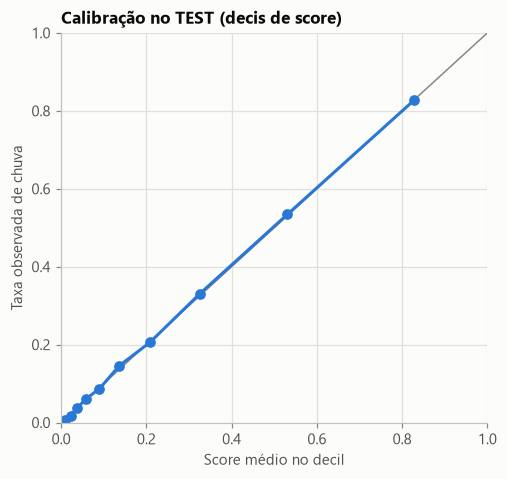

In [20]:
calib = pd.DataFrame({"score": s_test, "y": y_test})
calib["decil"] = pd.qcut(calib["score"], 10, labels=False, duplicates="drop") + 1
calib_table = calib.groupby("decil").agg(n=("y", "size"), score_medio=("score", "mean"), taxa_observada=("y", "mean"))
display(calib_table)
print(f"score médio no TEST {s_test.mean():.4f} × prevalência {y_test.mean():.4f}")
fig, ax = plt.subplots(figsize=(5, 4.6))
ax.plot([0, 1], [0, 1], color=plots.MUTED, linewidth=1)
ax.plot(calib_table["score_medio"], calib_table["taxa_observada"], color=plots.SERIES[0], marker="o", markersize=6)
ax.set(xlabel="Score médio no decil", ylabel="Taxa observada de chuva", title="Calibração no TEST (decis de score)",
       xlim=(0, 1), ylim=(0, 1))
plt.show()

**Leitura.** Em todos os decis o score médio fica próximo da taxa observada (decil 10: 0,827 previsto × 0,827 observado;
decil 6: 0,136 × 0,146), e o score médio no TEST (0,2246) é praticamente a prevalência (0,2252). No histórico, a saída pode ser
lida como probabilidade — consequência de `class_weight=None` (com `"balanced"` os scores seriam deslocados para cima). Calibração
não é métrica de comparação do projeto e não entrou em nenhuma escolha.

### 9.3 Coeficientes

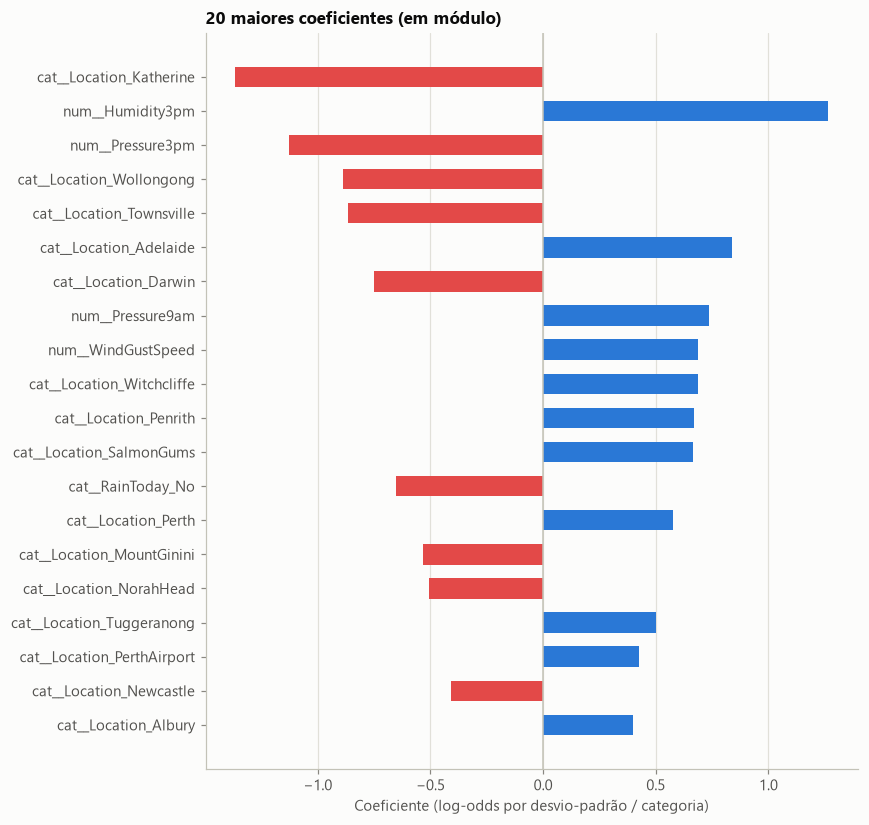

,feature,coefficient,abs_coefficient
0,cat__Location_Katherine,-1.3658,1.3658
1,num__Humidity3pm,1.2658,1.2658
2,num__Pressure3pm,-1.1276,1.1276
3,cat__Location_Wollongong,-0.8877,0.8877
4,cat__Location_Townsville,-0.8652,0.8652
5,cat__Location_Adelaide,0.8396,0.8396
6,cat__Location_Darwin,-0.7518,0.7518
7,num__Pressure9am,0.7352,0.7352
8,num__WindGustSpeed,0.6890,0.6890
9,cat__Location_Witchcliffe,0.6886,0.6886


In [21]:
coefs = coefficient_table(model)
plots.plot_coefficients(coefs, top_n=20)
plt.show()
display(coefs.head(12))

**Leitura (log-odds; numéricas por desvio-padrão do TRAIN).**
- **Maiores efeitos numéricos:** `Humidity3pm` (+1,27: tarde úmida aumenta a chance de chuva), `Pressure3pm` (−1,13) e `Pressure9am`
  (+0,74). Os sinais opostos das duas pressões indicam que o modelo usa, na prática, a **queda de pressão ao longo do dia**.
  `WindGustSpeed` (+0,69) e `RainToday = No` (−0,65, persistência) completam os principais.
- **Muitos dos maiores coeficientes são de `Location`:** capturam diferenças entre estações que as variáveis meteorológicas não
  explicam (as estações do norte — Katherine, Darwin, Townsville — têm efeito negativo, condicional às demais features). Com one-hot
  sem categoria de referência e L2, cada coeficiente de localidade é relativo ao conjunto das outras e também absorve a ausência
  estrutural de variáveis em algumas estações.
- Variáveis correlacionadas (pressões, umidades, temperaturas) dividem o efeito entre si; coeficientes individuais não são efeitos
  causais.

### 9.4 Variação histórica: desempenho do TEST por ano

Referência para julgar a variação que aparecerá no OOT: quanto as métricas oscilam entre anos dentro do próprio histórico.

In [22]:
by_year_test = metrics_by_group(test["Date"].dt.year.to_numpy(), y_test, s_test, key_name="ano", with_ci=False)
display(by_year_test[["ano", "n", "prevalence", "roc_auc", "pr_auc", "ks", "status"]])

,ano,n,prevalence,roc_auc,pr_auc,ks,status
0,2007,16,0.3750,NaN,NaN,NaN,insufficient_volume
1,2008,425,0.2565,0.8575,0.6980,0.5738,ok
2,2009,3361,0.2214,0.8823,0.7269,0.6014,ok
3,2010,3269,0.2325,0.8930,0.7504,0.6359,ok
4,2011,3038,0.2604,0.8739,0.7507,0.5913,ok
5,2012,3012,0.2165,0.8929,0.7204,0.6296,ok
6,2013,3194,0.2188,0.8738,0.7144,0.5775,ok
7,2014,3471,0.2031,0.8769,0.6823,0.5822,ok
8,2015,3446,0.2174,0.8716,0.6941,0.5786,ok
9,2016,3514,0.2299,0.8471,0.6806,0.5477,ok


**Leitura.** Dentro do próprio histórico o desempenho por ano já varia: no TEST, ROC-AUC de 0,847 (2016) a 0,893 (2010),
PR-AUC de 0,681 a 0,751 e KS de 0,548 a 0,636 (anos com ≥ 200 linhas; 2007 tem só 16 linhas no TEST e fica sem métrica). Cada ano
de 2009 a 2016 tem 3.000–3.500 linhas no TEST. Essa é a escala de variação "normal" contra a qual o OOT será lido. 2016, o ano mais
recente, tem o menor ROC-AUC e o menor KS da série — um ponto a observar, não uma conclusão.

---
## 10. Abertura do OOT 2017 (depois do congelamento)

Até aqui, 2017 só apareceu em contagens estruturais. O modelo avaliado abaixo é o artefato congelado por `train.py` (hash conferido
por `load_frozen_model`); nenhum `fit` é executado daqui em diante.

    TRAIN -> fit preprocessing + fit LogisticRegression
    TEST  -> transform + predict_proba
    OOT   -> transform + predict_proba

**Diagnósticos pós-OOT.** A linha "Teste (só jan-jun)" e a razão PR-AUC/prevalência abaixo, assim como a seção 13.1, foram
calculadas **depois** da avaliação, só para interpretar os resultados; não alteram o modelo nem as métricas oficiais de
`metrics.json`.

In [23]:
from src.data import load_oot_data
from src.evaluation import monthly_performance, target_drift_report, feature_drift_report

print("modelo congelado em:", meta["frozen_at_utc"])
print("OOT avaliado por evaluate.py em:", frozen_metrics.get("oot_evaluated_at_utc"))
oot_all = load_oot_data()
oot, n_missing_oot = drop_missing_target(oot_all)
X_oot, y_oot = get_xy(oot)
s_oot = model.predict_proba(X_oot)[:, 1]
oot_m = evaluate_scores(y_oot, s_oot)
for m in ("roc_auc", "pr_auc", "ks"):
    assert abs(oot_m[m] - frozen_metrics["oot"][m]) < 1e-12  # igual ao registrado por evaluate.py
persist_oot = discrimination_metrics(y_oot, persistence_score(X_oot))
# Todas as linhas de 2017 (inclusive sem target) recebem score: usado no drift do score, como em evaluate.py.
s_oot_all = model.predict_proba(oot_all.drop(columns=["RainTomorrow"]))[:, 1]
print(f"OOT: {len(oot_all)} linhas, {n_missing_oot} sem target, {len(oot)} avaliadas")

# Referência sazonal (diagnóstico pós-OOT, só TEST): o TEST histórico restrito aos mesmos meses do OOT.
jan_jun = test["Date"].dt.month.isin(sorted(oot["Date"].dt.month.unique())).to_numpy()
test_jj = evaluate_scores(y_test[jan_jun], s_test[jan_jun])

def _row(res, ci=True):
    out = {m: res[m] for m in ("roc_auc", "pr_auc", "ks")}
    if ci:
        out.update({f"{m}_ic95": f"[{res[f'{m}_ci_low']:.4f}, {res[f'{m}_ci_high']:.4f}]" for m in ("roc_auc", "pr_auc", "ks")})
    out["prevalência"] = res["prevalence"]
    out["n"] = res["n"]
    return out

comparison = pd.DataFrame({"Teste": _row(test_m), "Teste (só jan-jun)": _row(test_jj), "OOT 2017": _row(oot_m)}).T
display(comparison)
delta = pd.DataFrame({
    "OOT − Teste": {m: oot_m[m] - test_m[m] for m in ("roc_auc", "pr_auc", "ks", "prevalence")},
    "OOT − Teste (jan-jun)": {m: oot_m[m] - test_jj[m] for m in ("roc_auc", "pr_auc", "ks", "prevalence")},
}).T
display(delta)
lift = pd.Series({"Teste": test_m["pr_auc"] / test_m["prevalence"], "OOT 2017": oot_m["pr_auc"] / oot_m["prevalence"]},
                 name="PR-AUC / prevalência")
display(lift.to_frame().T)
display(pd.DataFrame({"persistência TEST": persist_test, "persistência OOT": persist_oot}).T[["roc_auc", "pr_auc", "ks", "prevalence"]])

modelo congelado em: 2026-09-28T22:41:09+00:00
OOT avaliado por evaluate.py em: 2026-09-28T23:12:29+00:00


OOT: 8623 linhas, 157 sem target, 8466 avaliadas


,roc_auc,pr_auc,ks,roc_auc_ic95,pr_auc_ic95,ks_ic95,prevalência,n
Teste,0.8757,0.7138,0.5839,"[0.8707, 0.8807]","[0.7026, 0.7254]","[0.5739, 0.5970]",0.2252,26746
Teste (só jan-jun),0.8812,0.7211,0.5959,"[0.8745, 0.8878]","[0.7048, 0.7361]","[0.5812, 0.6135]",0.2206,12835
OOT 2017,0.8653,0.6740,0.5682,"[0.8553, 0.8740]","[0.6509, 0.6969]","[0.5506, 0.5912]",0.2082,8466


,roc_auc,pr_auc,ks,prevalence
OOT − Teste,-0.0104,-0.0398,-0.0156,-0.0169
OOT − Teste (jan-jun),-0.0159,-0.0471,-0.0277,-0.0123


,Teste,OOT 2017
PR-AUC / prevalência,3.1697,3.2367


,roc_auc,pr_auc,ks,prevalence
persistência TEST,0.6608,0.3410,0.3220,0.2252
persistência OOT,0.6688,0.3325,0.3376,0.2082


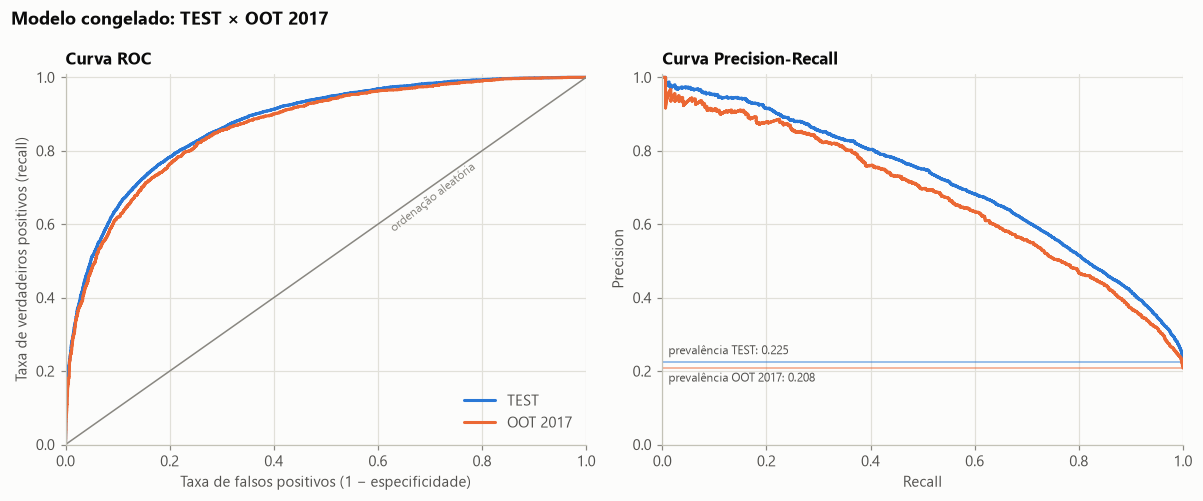

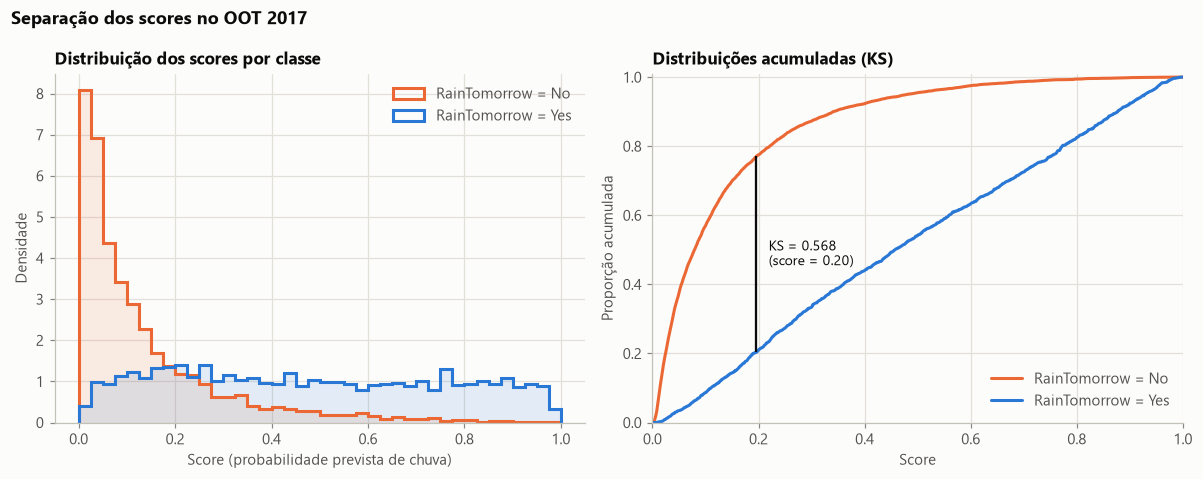

In [24]:
plots.plot_roc_pr({"TEST": (y_test, s_test), "OOT 2017": (y_oot, s_oot)}, title="Modelo congelado: TEST × OOT 2017")
plt.show()
plots.plot_score_distributions(y_oot, s_oot, title="Separação dos scores no OOT 2017")
plt.show()

**Leitura: TEST × OOT 2017.**
- **OOT** (8.466 dias rotulados de 8.623; 157 sem alvo): ROC-AUC **0,8653** [0,8553–0,8740], PR-AUC **0,6740** [0,6509–0,6969],
  KS **0,5682** [0,5506–0,5912], prevalência 0,208.
- **Diferença para o TEST:** ROC-AUC −0,0104 (−1,2%), PR-AUC −0,0398 (−5,6%), KS −0,0156 (−2,7%). **A PR-AUC foi a métrica que
  mais mudou.**
- **Tamanho da mudança.** A queda de ROC-AUC é bem maior que o erro-padrão da CV (0,0007), mas menor que a variação entre anos do
  próprio TEST (0,847–0,893, seção 9.4); 2017 fica acima de 2016 (0,847). Contra o TEST **dos mesmos meses** (jan–jun: 0,8812
  [0,8745–0,8878]) a queda é de 0,016, com intervalos que não se sobrepõem: a sazonalidade **não** explica a perda. Leio a queda de
  ROC-AUC e KS como **pequena a moderada** e a de PR-AUC como **moderada**.
- **PR-AUC e prevalência.** A prevalência caiu de 0,225 para 0,208. PR-AUC dividida pela prevalência: 3,17 no TEST e 3,24 no OOT — a
  maior parte da queda de PR-AUC acompanha a menor frequência de chuva, não uma pior ordenação.
- **Persistência** ("choveu hoje"): ROC-AUC 0,669 no OOT e 0,661 no TEST — o problema não mudou de dificuldade para essa regra
  ingênua, e o modelo continua muito acima dela.
- **Uma performance pior no OOT não significa necessariamente um modelo "errado".** Hipóteses investigadas nas seções 11–13:
  variação normal entre anos, composição sazonal (só jan–jun), mudança na taxa de chuva, mudança no fornecimento de dados (missing)
  e ruído amostral. Soma-se o otimismo do TEST aleatório (dias vizinhos da mesma estação caem em TRAIN e TEST).

## 11. Estabilidade temporal da performance (OOT por mês)

Regra fixada antes de abrir o OOT: uma janela só é avaliada com pelo menos 200 linhas e 30 casos de cada classe; caso contrário a
métrica fica vazia com o motivo. Intervalos de 95% por bootstrap (1.000 reamostragens). Como referência sazonal, o mesmo mês do
calendário no TEST histórico (anos < 2017).

,period,days_covered,n,n_pos,prevalence,roc_auc,roc_auc_ci_low,roc_auc_ci_high,pr_auc,pr_auc_ci_low,pr_auc_ci_high,ks,ks_ci_low,ks_ci_high,mean_score,status
0,2017-01,31,1492,298,0.1997,0.8207,0.7915,0.8530,0.6465,0.5933,0.6984,0.5027,0.4638,0.5695,0.2113,ok
1,2017-02,28,1345,284,0.2112,0.8655,0.8419,0.8863,0.6385,0.5819,0.6949,0.5841,0.5435,0.6365,0.2055,ok
2,2017-03,31,1480,412,0.2784,0.8736,0.8543,0.8918,0.7464,0.7051,0.7856,0.5845,0.5464,0.6349,0.2676,ok
3,2017-04,30,1451,287,0.1978,0.8708,0.8495,0.8933,0.6826,0.6322,0.7361,0.5669,0.5262,0.6244,0.1806,ok
4,2017-05,31,1501,293,0.1952,0.8712,0.8497,0.8928,0.6612,0.6025,0.7184,0.6144,0.5728,0.6608,0.1966,ok
5,2017-06,25,1197,189,0.1579,0.8822,0.8563,0.9077,0.6382,0.5648,0.7106,0.6118,0.5627,0.6726,0.1793,ok


,period,hist_test_n,hist_test_prevalence,hist_test_roc_auc,hist_test_pr_auc,hist_test_ks,delta_roc_auc_vs_hist_test,delta_pr_auc_vs_hist_test,delta_ks_vs_hist_test
0,2017-01,2303,0.1889,0.8789,0.6876,0.6033,-0.0582,-0.0411,-0.1006
1,2017-02,1782,0.2110,0.8971,0.7612,0.6313,-0.0315,-0.1227,-0.0471
2,2017-03,2245,0.1987,0.8614,0.6770,0.5652,0.0122,0.0694,0.0192
3,2017-04,1935,0.2145,0.8782,0.7266,0.5966,-0.0074,-0.0441,-0.0297
4,2017-05,2396,0.2354,0.8912,0.7385,0.6123,-0.0200,-0.0773,0.0022
5,2017-06,2174,0.2737,0.8736,0.7371,0.6126,0.0086,-0.0989,-0.0008


janelas com volume insuficiente: nenhuma
critério de melhor/pior mês: roc_auc | melhor: 2017-06 | pior: 2017-01


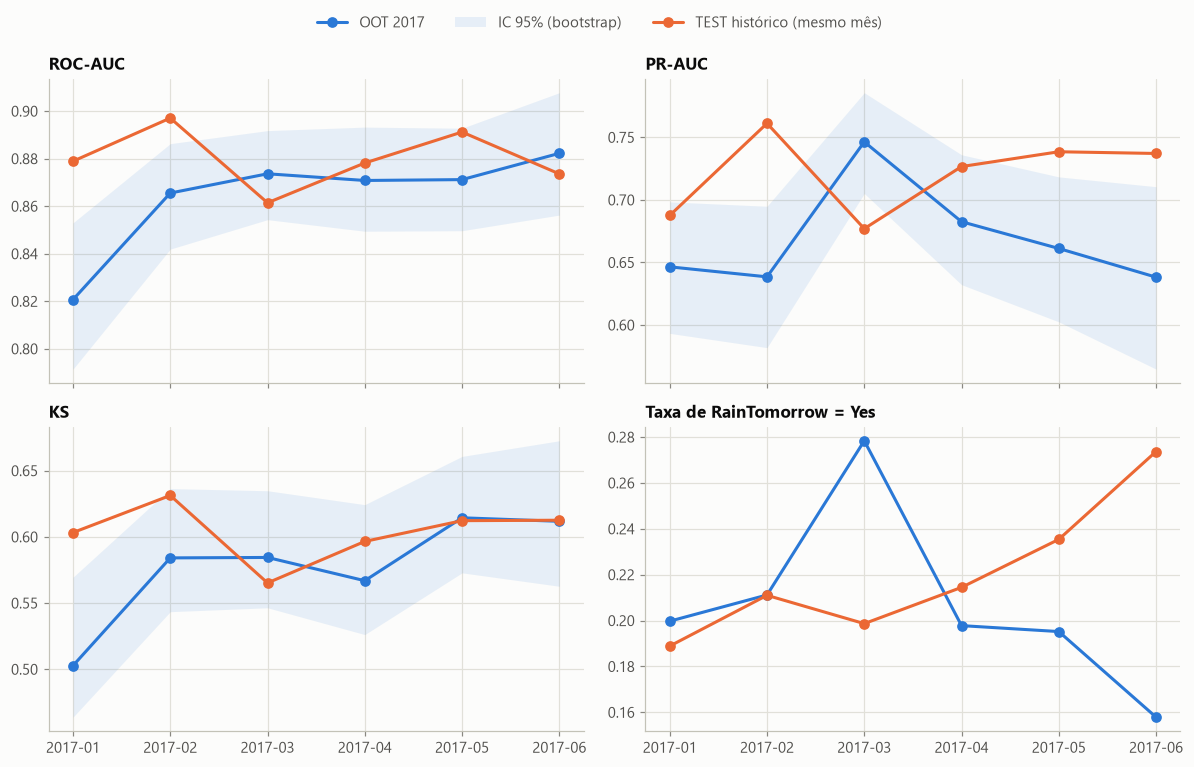

amplitude entre meses (máx − mín): {'roc_auc': 0.0615, 'pr_auc': 0.1081, 'ks': 0.1117, 'prevalence': 0.1205}


In [25]:
monthly = monthly_performance(oot, y_oot, s_oot, test, y_test, s_test)
frozen_monthly = pd.read_csv(config.TEMPORAL_PERFORMANCE_PATH)
np.testing.assert_allclose(monthly["roc_auc"], frozen_monthly["roc_auc"], rtol=0, atol=1e-12)
show = ["period", "days_covered", "n", "n_pos", "prevalence", "roc_auc", "roc_auc_ci_low", "roc_auc_ci_high", "pr_auc",
        "pr_auc_ci_low", "pr_auc_ci_high", "ks", "ks_ci_low", "ks_ci_high", "mean_score", "status"]
display(monthly[show])
display(monthly[["period", "hist_test_n", "hist_test_prevalence", "hist_test_roc_auc", "hist_test_pr_auc", "hist_test_ks",
                 "delta_roc_auc_vs_hist_test", "delta_pr_auc_vs_hist_test", "delta_ks_vs_hist_test"]])
insufficient = monthly[monthly["status"] != "ok"]
print("janelas com volume insuficiente:", "nenhuma" if insufficient.empty else insufficient[["period", "n", "status"]].to_dict("records"))
best_worst = frozen_metrics["oot_months"]
print(f"critério de melhor/pior mês: {best_worst['ranking_metric']} | melhor: {best_worst['best']['period']} | pior: {best_worst['worst']['period']}")
ref_cols = {f"hist_test_{m}": m for m in ["roc_auc", "pr_auc", "ks", "prevalence"]}
plots.plot_monthly_performance(monthly, monthly[["month", *ref_cols]].rename(columns=ref_cols),
                               reference_label="TEST histórico (mesmo mês)")
plt.show()
print("amplitude entre meses (máx − mín):",
      {m: round(float(monthly[m].max() - monthly[m].min()), 4) for m in ("roc_auc", "pr_auc", "ks", "prevalence")})

**Leitura: estabilidade mensal.** As 6 janelas têm volume suficiente (1.197 a 1.501 dias; 189 a 412 positivos);
junho cobre só 25 dias.
- **ROC-AUC:** 0,821 (jan), 0,866 (fev), 0,874 (mar), 0,871 (abr), 0,871 (mai), 0,882 (jun). De fevereiro a junho a variação é pequena
  (0,866–0,882, intervalos sobrepostos). **Janeiro destoa:** 0,821 [0,791–0,853], abaixo do janeiro histórico do TEST (0,879), com KS
  0,503 (histórico 0,603). Fevereiro também fica abaixo do seu histórico (0,897, fora do intervalo); março a junho ficam compatíveis com
  o histórico do mesmo mês. Não há tendência de queda ao longo do semestre.
- **Melhor e pior mês** (critério definido antes de abrir o OOT: ROC-AUC): **junho/2017 (0,882)** e **janeiro/2017 (0,821)**.
- **A PR-AUC oscila muito mais (0,638–0,746) e acompanha a taxa de chuva:** o maior valor é o de março (0,746), o mês mais chuvoso
  (27,8%); os menores são junho (0,638, taxa 15,8%) e fevereiro (0,639). O melhor mês por ROC-AUC é um dos piores por PR-AUC.
- **KS** vai de 0,503 (jan) a 0,614 (mai), no mesmo padrão do ROC-AUC.
- O **score médio** acompanha a taxa de chuva de cada mês (jan: 0,211 × 0,200; mar: 0,268 × 0,278; jun: 0,179 × 0,158): o modelo
  reagiu ao mês chuvoso e ao mês seco na direção certa, sem nenhum ajuste.
- **Resumo:** ordenação estável de fevereiro a junho e um janeiro fraco. A métrica agregada do OOT (0,865) esconde uma diferença de
  0,06 de ROC-AUC entre o pior e o melhor mês.

## 12. Target drift

,train,test,oot,oot_expected_from_train_seasonality,train_same_months_as_oot
taxa de RainTomorrow = Yes,0.2252,0.2252,0.2082,0.2204,0.2222


,month,train_n,train_rate,test_n,test_rate,oot_n,oot_rate,oot_minus_train
0,1,9126,0.1934,2303,0.1889,1492.0000,0.1997,0.0063
1,2,7398,0.2091,1782,0.2110,1345.0000,0.2112,0.0020
2,3,9311,0.2065,2245,0.1987,1480.0000,0.2784,0.0718
3,4,7920,0.2223,1935,0.2145,1451.0000,0.1978,-0.0246
4,5,9158,0.2276,2396,0.2354,1501.0000,0.1952,-0.0324
5,6,9018,0.2728,2174,0.2737,1197.0000,0.1579,-0.1149
6,7,9354,0.2735,2425,0.2528,NaN,NaN,NaN
7,8,9405,0.2523,2357,0.2533,NaN,NaN,NaN
8,9,9013,0.2272,2332,0.2393,NaN,NaN,NaN
9,10,9468,0.1950,2336,0.1986,NaN,NaN,NaN


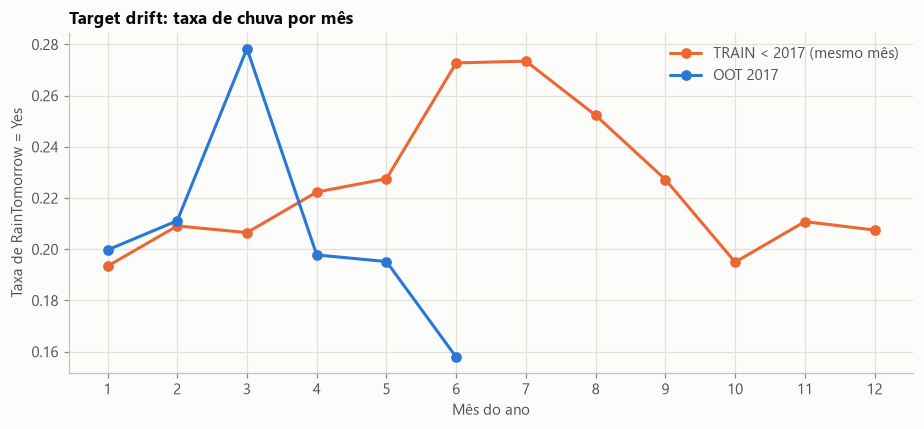

In [26]:
by_month_rate, rates = target_drift_report(train, test, oot)
display(pd.Series(rates, name="taxa de RainTomorrow = Yes").to_frame().T)
display(by_month_rate)
plots.plot_target_rate(by_month_rate)
plt.show()

**Leitura: target drift.**
- Taxa de `RainTomorrow = Yes`: **TRAIN 0,2252, TEST 0,2252, OOT 0,2082.**
- A diferença não é só sazonal: aplicando a taxa histórica de cada mês à composição de meses do OOT, o esperado seria 0,2204 (TRAIN
  só jan–jun: 0,2222). **2017 ficou ~1,2 ponto percentual abaixo do esperado para a estação.**
- Por mês, 2017 fugiu do padrão em direções opostas: **março muito mais chuvoso** (27,8% × 20,7% no TRAIN, +7,2 p.p.) e **junho muito
  mais seco** (15,8% × 27,3%, −11,5 p.p.); abril e maio também mais secos (−2,5 e −3,2 p.p.); janeiro e fevereiro próximos do histórico.
- **Efeito nas métricas:** a menor prevalência ajuda a explicar a queda da PR-AUC (seção 10) e a oscilação mensal da PR-AUC
  (seção 11). ROC-AUC e KS não dependem da prevalência e, de fato, não seguem a taxa: junho, o mês mais seco, tem o maior ROC-AUC.

## 13. Feature drift: PSI e KS (TRAIN → OOT 2017)

- **PSI:** bins = decis de cada feature **no TRAIN** (bordas repetidas colapsam em variáveis discretas ou com muitos zeros) + um bin
  para missing; as mesmas bordas são aplicadas ao OOT. Leitura heurística: < 0,10 pouca mudança; 0,10–0,25 atenção; > 0,25 relevante.
- **KS de drift:** estatística de duas amostras entre os valores observados no TRAIN e no OOT. O p-value é mostrado, mas com dezenas de
  milhares de linhas qualquer diferença mínima fica "significativa"; a leitura é pelo tamanho da estatística.
- **Duas referências**, para separar sazonalidade de mudança estrutural: TRAIN com todos os meses (o pedido pelo enunciado) e TRAIN
  apenas de janeiro a junho (mesma estação do OOT). Também estão incluídos `Location` (PSI categórico) e o **score do modelo**.
- O drift usa **todas as 8.623 linhas de 2017** (a distribuição das entradas não depende de o alvo existir). `MaxTemp` aparece como
  informação sobre os dados, marcada `in_model = False`.

,in_model,ks_statistic | TRAIN (mesmos meses do OOT: jan-jun),ks_statistic | TRAIN (todos os meses),psi | TRAIN (mesmos meses do OOT: jan-jun),psi | TRAIN (todos os meses)
feature,,,,,
Sunshine,True,0.0427,0.0248,0.3734,0.3409
Evaporation,True,0.0837,0.0820,0.3002,0.2806
Cloud3pm,True,0.1114,0.1091,0.1547,0.1432
Temp3pm,True,0.0376,0.1165,0.0827,0.1364
MaxTemp,False,0.0439,0.1144,0.0281,0.0907
Cloud9am,True,0.1143,0.1149,0.0877,0.0855
MinTemp,True,0.0362,0.1113,0.0216,0.0787
Humidity3pm,True,0.0238,0.0178,0.0653,0.0604
WindSpeed3pm,True,0.0422,0.0788,0.0398,0.0537


,ref_missing_rate,cur_missing_rate,ref_median,cur_median,Δ missing
feature,,,,,
Sunshine,0.4612,0.7413,8.5000,8.6000,0.2801
Evaporation,0.4139,0.6672,4.6000,5.4000,0.2532
Cloud3pm,0.3933,0.5468,5.0000,5.0000,0.1535
Cloud9am,0.3724,0.4677,5.0000,6.0000,0.0953
Humidity3pm,0.0228,0.0689,52.0000,53.0000,0.0461
Temp3pm,0.0166,0.0619,21.0000,22.9000,0.0453
WindSpeed3pm,0.0173,0.0419,19.0000,17.0000,0.0246
MinTemp,0.0042,0.0123,11.9000,13.9000,0.0081
Rainfall,0.0098,0.0176,0.0000,0.0000,0.0078


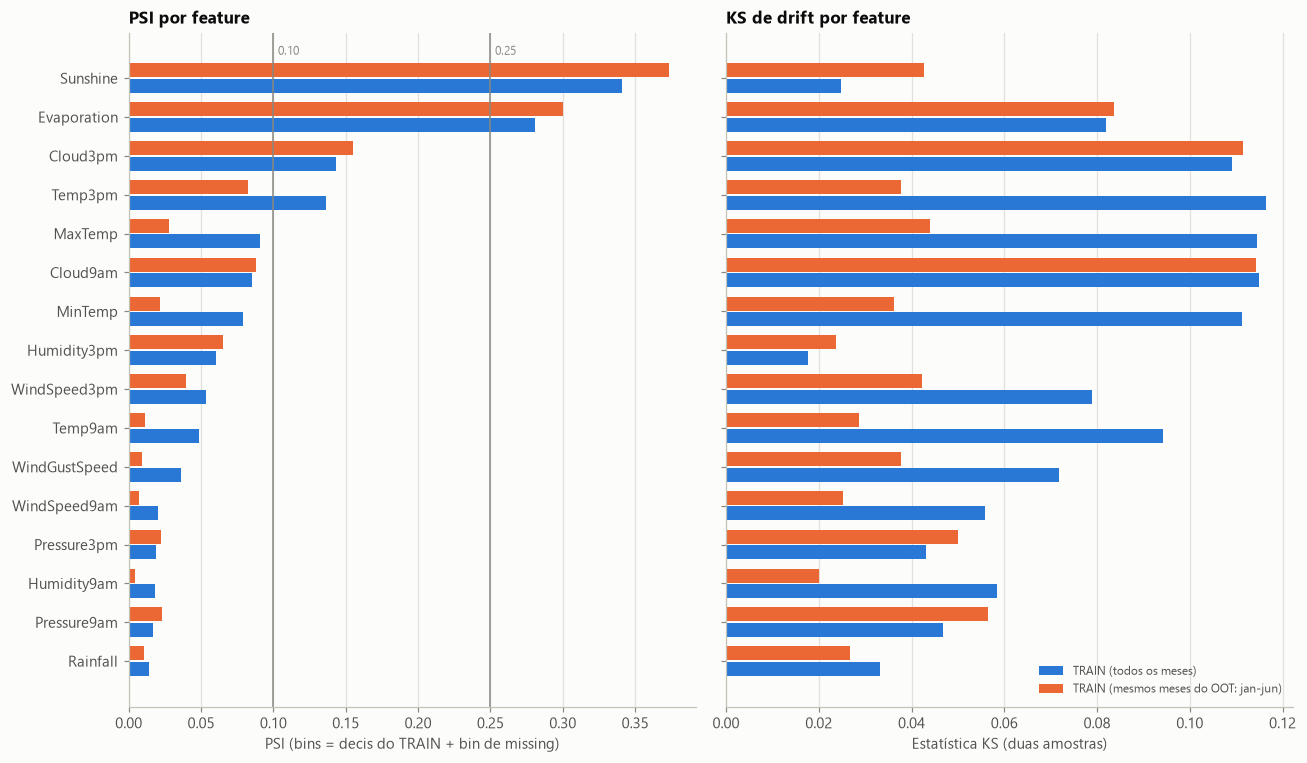

In [27]:
drift = feature_drift_report(train, oot_all, s_train, s_oot_all)
frozen_drift = pd.read_csv(config.DRIFT_REPORT_PATH)
np.testing.assert_allclose(drift["psi"], frozen_drift["psi"], rtol=0, atol=1e-12)
wide = drift.pivot_table(index="feature", columns="reference", values=["psi", "ks_statistic"])
wide.columns = [f"{a} | {b}" for a, b in wide.columns]
order = drift[drift["reference"] == "TRAIN (todos os meses)"].set_index("feature")["psi"].sort_values(ascending=False).index
wide = wide.loc[order]
wide.insert(0, "in_model", drift.drop_duplicates("feature").set_index("feature").loc[order, "in_model"])
display(wide)
missing_shift = (drift[(drift["reference"] == "TRAIN (todos os meses)") & (drift["type"] == "numérica")]
                 .set_index("feature")[["ref_missing_rate", "cur_missing_rate", "ref_median", "cur_median"]])
missing_shift["Δ missing"] = missing_shift["cur_missing_rate"] - missing_shift["ref_missing_rate"]
display(missing_shift.sort_values("Δ missing", ascending=False))
plots.plot_drift(drift[drift["type"] == "numérica"])
plt.show()

**Leitura crítica: feature drift (TRAIN → OOT 2017).**
- **PSI acima de ~0,25:** `Sunshine` (0,341) e `Evaporation` (0,281). **Entre ~0,10 e ~0,25:** `Cloud3pm` (0,143) e `Temp3pm` (0,136).
  As demais features do modelo ficam abaixo de 0,10; `Location`, 0,025.
- **O PSI alto de `Sunshine` e `Evaporation` vem do bin de missing, não dos valores.** A fração ausente subiu de 46% para 74%
  (`Sunshine`) e de 41% para 67% (`Evaporation`), enquanto o KS entre os valores observados é pequeno (0,025 e 0,082). O mesmo, em
  menor escala, em `Cloud3pm` (39% → 55%), `Cloud9am` (37% → 47%) e nas leituras das 15h (`Temp3pm` 1,7% → 6,2%; `Humidity3pm`
  2,3% → 6,9%). É mudança no **fornecimento dos dados**, não no clima (seção 13.1).
- **Sazonalidade.** Com a referência TRAIN jan–jun, o drift das temperaturas quase desaparece: KS de `Temp3pm` 0,116 → 0,038, `MinTemp`
  0,111 → 0,036, `Temp9am` 0,094 → 0,029 (e `MaxTemp`, fora do modelo, 0,114 → 0,044). Era composição de estação: o OOT só tem
  verão e outono.
- **O que não é sazonal:** nuvens. KS ≈ 0,11 em `Cloud9am` e `Cloud3pm` nas duas referências (mediana de `Cloud9am` de 5 para 6
  oitavos). Pode ser efeito de composição (quatro estações deixaram de reportar `Cloud3pm`); hipótese não testada aqui.
- **Score do modelo:** PSI 0,010 e KS 0,027; média 0,225 no TRAIN e 0,210 no OOT, em linha com a menor taxa de chuva. A
  distribuição de saída quase não mudou.
- Os cortes de PSI são leitura heurística, não regra. Com amostras tão grandes, quase todos os p-values do KS ficam abaixo de 0,05
  mesmo para estatísticas de 0,02–0,05; a leitura é pelo tamanho da estatística.

### 13.1 Diagnóstico pós-OOT: de onde vem o aumento de missing?

Análise exploratória **depois** da avaliação final, só para interpretar os resultados. Nada aqui altera o modelo, o preprocessing
ou qualquer métrica reportada.

In [28]:
feats = ["Sunshine", "Evaporation", "Cloud9am", "Cloud3pm"]
miss_train = train.groupby("Location")[feats].agg(lambda s: s.isna().mean())
miss_oot = oot_all.groupby("Location")[feats].agg(lambda s: s.isna().mean())
for f in feats:
    stopped = sorted(miss_train.index[(miss_train[f] < 0.5) & (miss_oot[f] > 0.95)])
    print(f"{f}: {len(stopped)} estações mediam no TRAIN (< 50% missing) e não medem em 2017 (> 95% missing): {stopped}")

sun_stopped = miss_train.index[(miss_train["Sunshine"] < 0.5) & (miss_oot["Sunshine"] > 0.95)]
last_obs = train[train["Location"].isin(sun_stopped)].dropna(subset=["Sunshine"]).groupby("Location")["Date"].max()
print("último Sunshine observado no TRAIN nessas estações:", last_obs.dt.to_period("M").value_counts().sort_index().to_dict())
display(oot_all.groupby(oot_all["Date"].dt.to_period("M"))[feats].agg(lambda s: s.isna().mean()).rename_axis("mês (2017)"))

rows = {}
for f in ["Sunshine", "Evaporation"]:
    miss = oot[f].isna().to_numpy()
    rows[f"OOT, {f} observado"] = discrimination_metrics(y_oot[~miss], s_oot[~miss])
    rows[f"OOT, {f} ausente"] = discrimination_metrics(y_oot[miss], s_oot[miss])
yr, mo = test["Date"].dt.year.to_numpy(), test["Date"].dt.month.to_numpy()
for label, mask in [("TEST 2009-2015, mai-dez", (yr >= 2009) & (yr <= 2015) & (mo >= 5)),
                    ("TEST 2016, mai-dez", (yr == 2016) & (mo >= 5)),
                    ("TEST 2009-2015, jan-abr", (yr >= 2009) & (yr <= 2015) & (mo <= 4)),
                    ("TEST 2016, jan-abr", (yr == 2016) & (mo <= 4))]:
    rows[label] = {**discrimination_metrics(y_test[mask], s_test[mask]),
                   "sunshine_missing": float(test.loc[mask, "Sunshine"].isna().mean())}
display(pd.DataFrame(rows).T[["n", "prevalence", "roc_auc", "pr_auc", "ks", "sunshine_missing"]])

Sunshine: 15 estações mediam no TRAIN (< 50% missing) e não medem em 2017 (> 95% missing): ['Adelaide', 'Albany', 'AliceSprings', 'Cairns', 'CoffsHarbour', 'Dartmoor', 'Moree', 'MountGambier', 'NorfolkIsland', 'Portland', 'Sale', 'Townsville', 'WaggaWagga', 'Williamtown', 'Woomera']
Evaporation: 11 estações mediam no TRAIN (< 50% missing) e não medem em 2017 (> 95% missing): ['Adelaide', 'Cairns', 'Canberra', 'Cobar', 'CoffsHarbour', 'Dartmoor', 'Moree', 'MountGambier', 'Portland', 'Sale', 'Williamtown']
Cloud9am: 0 estações mediam no TRAIN (< 50% missing) e não medem em 2017 (> 95% missing): []
Cloud3pm: 4 estações mediam no TRAIN (< 50% missing) e não medem em 2017 (> 95% missing): ['Albany', 'Katherine', 'Newcastle', 'Nuriootpa']
último Sunshine observado no TRAIN nessas estações: {Period('2014-04', 'M'): 3, Period('2016-04', 'M'): 11, Period('2016-11', 'M'): 1}


,Sunshine,Evaporation,Cloud9am,Cloud3pm
mês (2017),,,,
2017-01,0.7413,0.6689,0.4562,0.5405
2017-02,0.7398,0.6363,0.4825,0.5700
2017-03,0.7400,0.6524,0.4654,0.5418
2017-04,0.7422,0.6592,0.4701,0.5218
2017-05,0.7433,0.6728,0.4773,0.5444
2017-06,0.7410,0.7206,0.4534,0.5678


,n,prevalence,roc_auc,pr_auc,ks,sunshine_missing
"OOT, Sunshine observado",2216,0.2008,0.8721,0.6977,0.6068,NaN
"OOT, Sunshine ausente",6250,0.2109,0.8629,0.6656,0.5562,NaN
"OOT, Evaporation observado",2822,0.1963,0.8745,0.6815,0.6130,NaN
"OOT, Evaporation ausente",5644,0.2142,0.8604,0.6713,0.5481,NaN
"TEST 2009-2015, mai-dez",15698,0.2324,0.8796,0.7214,0.5928,0.4379
"TEST 2016, mai-dez",2380,0.2521,0.8413,0.6905,0.5506,0.7235
"TEST 2009-2015, jan-abr",7093,0.2047,0.8810,0.7159,0.5940,0.4182
"TEST 2016, jan-abr",1134,0.1834,0.8543,0.6588,0.5678,0.5379


**Leitura (diagnóstico, não causal).**
- 15 estações que mediam `Sunshine` no TRAIN não medem em 2017; no TRAIN, 11 delas têm o último valor em abril de 2016 (3 em abril
  de 2014, 1 em novembro de 2016). Para `Evaporation`, 11 estações pararam. A fração ausente é praticamente constante nos seis meses
  de 2017 (~74% em `Sunshine`): é uma mudança de regime no fornecimento que começa ainda dentro do período de treino.
- Para o modelo, essas linhas passam a receber a mediana do TRAIN e o indicador de missing, cujo coeficiente foi aprendido sobretudo
  com estações que **nunca** mediram a variável — situação diferente.
- No OOT, linhas sem `Sunshine` têm ROC-AUC 0,863, contra 0,872 com o valor observado (`Evaporation`: 0,860 × 0,875). A comparação
  mistura estações diferentes e não isola causa.
- No histórico, o TEST de mai–dez/2016 (72% sem `Sunshine`) tem ROC-AUC 0,841, contra 0,880 nos mesmos meses de 2009–2015 (44% sem).
  Mas jan–abr/2016, com menos missing (54%), também ficou abaixo (0,854 × 0,881): 2016 foi mais difícil por mais de um motivo.
- **Conclusão do diagnóstico:** a mudança de missingness é a principal fonte de drift não sazonal e uma hipótese plausível para parte
  da perda — algo a monitorar e a tratar num próximo ciclo de desenvolvimento, não a "corrigir" com base no OOT.

## 14. Comparação final obrigatória

In [29]:
final = pd.DataFrame(frozen_metrics["final_comparison"]).set_index("set")
display(final[["roc_auc", "pr_auc", "ks", "prevalence", "n"]])

,roc_auc,pr_auc,ks,prevalence,n
set,,,,,
Teste,0.8757,0.7138,0.5839,0.2252,26746
OOT 2017,0.8653,0.6740,0.5682,0.2082,8466
Melhor mês do OOT (2017-06),0.8822,0.6382,0.6118,0.1579,1197
Pior mês do OOT (2017-01),0.8207,0.6465,0.5027,0.1997,1492


**Observações sobre a tabela.**
- **Teste:** 20% aleatório estratificado do histórico < 2017 (26.746 dias, prevalência 0,225); mede generalização dentro do período.
- **OOT 2017:** todas as linhas de jan–jun/2017 com alvo (8.466 dias, prevalência 0,208); responde à pergunta temporal.
- **Melhor mês (jun/2017):** ROC-AUC 0,882, mas é um mês parcial (25 dias) e o mais seco (15,8%); por isso a PR-AUC (0,638) está entre
  as menores.
- **Pior mês (jan/2017):** ROC-AUC 0,821 e KS 0,503, abaixo do janeiro histórico (0,879); taxa de chuva normal para o mês (20,0%).
- Critério de melhor/pior mês definido antes de abrir o OOT: ROC-AUC entre meses com ≥ 200 linhas e ≥ 30 casos de cada classe. Os seis
  meses se qualificaram.

## 15. Respostas às perguntas finais do enunciado

1. **Score/probabilidade × classe prevista.** O score é `predict_proba[:, 1]`, a probabilidade estimada de chover (ex.: 0,73). A classe
   só existe depois de um threshold (Yes se score ≥ t). Este projeto entrega o score; no TEST ele é bem calibrado (score médio 0,2246 ×
   prevalência 0,2252; seção 9.2).
2. **Por que accuracy é insuficiente.** Com 77,5% de dias sem chuva, responder sempre "No" tem accuracy 0,775 e recall zero. O modelo
   no corte 0,5 tem accuracy 0,850 mas recall 0,523 — a accuracy não mostra que quase metade dos dias de chuva passa despercebida.
3. **Precision, Recall, Specificity e F1 (TEST, corte ilustrativo 0,5).** Precision 0,734: de cada 100 avisos de chuva, 73 se
   confirmam. Recall 0,523: de cada 100 dias chuvosos, 52 foram avisados. Specificity 0,945: 94,5% dos dias secos foram reconhecidos
   como secos. F1 0,611 resume precision e recall; mudar o corte muda os três (seção 9.1).
4. **Métricas sem threshold.** ROC-AUC e PR-AUC percorrem todos os cortes possíveis e resumem a curva inteira; o KS é a maior
   separação entre as distribuições acumuladas dos scores das duas classes. As três dependem só da ordenação dos scores.
5. **ROC-AUC e PR-AUC contaram a mesma história?** Em parte. As duas caíram no OOT, mas a PR-AUC caiu quatro vezes mais (−0,040 × −0,010),
   porque depende da prevalência (0,225 → 0,208). Dentro de 2017 elas divergem: junho tem o maior ROC-AUC (0,882) e uma das menores
   PR-AUC (0,638, taxa de 15,8%); março tem a maior PR-AUC (0,746, taxa de 27,8%) com ROC-AUC mediano.
6. **Por que 0,5 não é o melhor threshold.** O corte ótimo depende do custo de um alarme falso × uma chuva não avisada e da prevalência.
   Com 22,5% de chuva, só 16% dos dias do TEST passam de 0,5, e a maior separação entre as classes (KS) ocorre por volta de 0,25.
   Nenhum corte foi escolhido aqui.
7. **Teste aleatório × OOT 2017.** O TEST é uma amostra aleatória do mesmo período do treino: mistura todos os anos e meses e tem dias
   vizinhos da mesma estação no TRAIN, o que o torna otimista. O OOT é um período posterior, nunca visto, com apenas janeiro–junho e
   com mudanças reais (menos chuva, mais dados ausentes). Só o OOT responde se o modelo funciona "quando o tempo avança".
8. **Três vazamentos que invalidariam o projeto.** (a) Usar informação do dia seguinte: um *lead* de `RainToday`/`Rainfall` (que é o
   próprio alvo), `RISK_MM`, ou `MaxTemp`, cuja janela termina às 09:00 de *t+1* (excluída). (b) Ajustar imputer, scaler ou encoder com
   TEST/OOT juntos ao TRAIN. (c) Olhar o desempenho de 2017 e voltar para mudar features, C ou preprocessing. Outros: usar o ano como
   feature, ou agregados por estação calculados com o período inteiro.
9. **A performance foi estável ao longo de 2017?** Quase: de fevereiro a junho o ROC-AUC fica entre 0,866 e 0,882 com intervalos
   sobrepostos; janeiro é a exceção (0,821, abaixo do janeiro histórico de 0,879). A PR-AUC oscila mais (0,638–0,746), acompanhando a
   taxa de chuva.
10. **Houve target drift?** Sim, moderado: a taxa de chuva foi 0,208 no OOT contra 0,225 no TRAIN/TEST e 0,220 esperado para jan–jun.
    Março/2017 foi muito mais chuvoso que o normal (+7,2 p.p.) e junho/2017 muito mais seco (−11,5 p.p.).
11. **Maior drift por PSI e KS.** PSI: `Sunshine` (0,34) e `Evaporation` (0,28), por causa do salto de valores ausentes (46% → 74% e
    41% → 67%); depois `Cloud3pm` (0,14) e `Temp3pm` (0,14). KS (valores observados): `Temp3pm` (0,116), `Cloud9am` (0,115), `MinTemp`
    (0,111) e `Cloud3pm` (0,109). O KS das temperaturas cai para ~0,04 com a referência jan–jun (sazonalidade); o das nuvens não.
12. **Drift significa que o modelo deixou de funcionar?** Não necessariamente. Aqui, parte do drift é sazonal (esperado) e os maiores
    valores de PSI vêm de dados ausentes, que o pipeline trata por imputação e indicadores. A distribuição do score quase não mudou (PSI 0,010),
    o ROC-AUC caiu 0,010 — dentro da variação histórica entre anos — e o modelo segue muito acima das referências. Drift é um alerta
    para investigar; o que decide é o desempenho, que teve perda real mas modesta (−0,016 contra o TEST dos mesmos meses), concentrada
    em janeiro.
13. **O que o script de inferência faz sem o notebook.** `predict.py` carrega o pipeline congelado, confere o SHA-256 contra
    `metadata.json`, valida as colunas de entrada, aplica exatamente o preprocessing aprendido no TRAIN (imputação, escala, one-hot, dia
    do ano), ignora colunas extras, gera `rain_probability` por linha na ordem de entrada e **não treina nada**. Não depende de nenhum
    estado de sessão de notebook.

## 16. Conclusões e limitações

**Resposta à pergunta central.** Sim, com uma perda pequena a moderada. O modelo desenvolvido com dados até 2016 mantém boa capacidade
de discriminar chuva e não chuva em 2017: ROC-AUC 0,865 no OOT contra 0,876 no TEST (0,881 no TEST dos mesmos meses), KS 0,568 contra
0,584, muito acima da persistência (0,669) e da ordenação aleatória (0,5). A PR-AUC caiu mais (0,714 → 0,674), em boa parte porque
2017 choveu menos que o normal. A perda de ordenação é real — não é explicada pela sazonalidade —, mas está dentro da variação entre
anos observada no próprio histórico e concentra-se em janeiro/2017.

**Por que a avaliação é válida.** 2017 foi separado antes de qualquer ajuste; todo preprocessing foi ajustado só no TRAIN; o protocolo
de seleção foi pré-registrado e aplicado só com CV no TRAIN; o modelo foi congelado com hash antes de abrir 2017, e o mesmo hash foi
verificado antes e depois da avaliação. `MaxTemp` foi excluída por fechar depois do momento da previsão.

**Drift.** A temperatura mudou por sazonalidade (o OOT só tem jan–jun). A principal mudança não sazonal é de **fornecimento de dados**:
15 estações deixaram de informar `Sunshine` e 11 deixaram de informar `Evaporation` a partir de 2016. É a hipótese mais plausível para
parte da perda e o primeiro item a monitorar.

**Limitações.**
- O OOT cobre um único semestre (jan–jun/2017, junho parcial): não mostra inverno e primavera de 2017 nem estabilidade de longo prazo.
- O TEST aleatório é otimista: dias vizinhos da mesma estação são muito parecidos e caem nos dois lados do split.
- Os intervalos de bootstrap tratam os dias como independentes; como há autocorrelação no tempo e entre estações no mesmo dia, eles
  são provavelmente estreitos demais.
- O alvo cobre das 09:00 de *t* às 09:00 de *t+1*; como a previsão usa observações da tarde de *t*, o problema é em parte *nowcasting*.
  Um modelo só com informação das 09:00 é bem pior (ROC-AUC 0,812 na CV).
- Chuva e evaporação podem vir acumuladas de vários dias após dias sem medição (nota do BoM): ruído no alvo e nas features.
- Um único efeito sazonal para a Austrália inteira (dia do ano) não captura regimes regionais (norte tropical × sul temperado).
- Localidades novas no futuro entrariam com one-hot zerado.

**Próximos passos (para um novo ciclo de desenvolvimento, não para este modelo).** Monitorar missingness por estação e ROC-AUC/PR-AUC
por mês; retreinar com dados mais recentes, em especial após a mudança de fornecimento de 2016; avaliar os meses seguintes de 2017
quando disponíveis; se houver uso operacional, escolher o threshold a partir de custos explícitos de FP e FN.